# **📊📈📉 Data Visualizations**

---
---
---
# **🟡 Univariate Plots**

| Variable Type   | Plot Types                                   |
| --------------- | -------------------------------------------- |
| **Numerical**   | Histogram, KDE, Boxplot, Violin, QQ Plot     |
| **Categorical** | Bar Chart / Countplot, Pie Chart, Word Cloud |

---
---
## **└─ (N) Histogram + KDE**

- A Histogram shows the distribution of a numerical variable by dividing the range into intervals (bins) and counting the number of observations in each bin
- A Kernel Density Estimate (KDE) is a smooth curve that estimates the probability density function of the variable — think of it as a smoothed version of the histogram.

**✅ When to Use:**

- To explore the distribution of a continuous variable.
- When you want to visually assess symmetry, skewness, modality (peaks), and spread.
- Useful for identifying if data is normally distributed.
- During univariate exploratory data analysis (EDA) to quickly understand the shape of the data.

**❌ When Not to Use:**

- For categorical variables — histograms and KDE are not appropriate.
- With very small datasets – KDE may give misleading shapes.
- If the variable has many extreme outliers, KDE may oversmooth or distort the distribution.
- When you need exact frequencies, stick to just the histogram.

**⚠️ Tip**

- Always check if the KDE assumption (continuous smooth data) is reasonable for your variable.
- Use KDE only when the sample size is large enough (rule of thumb: >30).

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_histogram(df, feature, bins=30, kde=True, color="steelblue", title=None):
    """
    Plot a histogram with KDE curve and statistical annotations for a numerical feature.

    Features:
    - Histogram with customizable bins and color.
    - Optional KDE curve for visualizing distribution shape.
    - Vertical lines for Mean and Median.
    - Legend showing Mean, Median, Skewness, and Kurtosis.
    - Prints distribution shape interpretation in the console.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Name of the numerical column to analyze.
        bins (int): Number of histogram bins (default: 30).
        kde (bool): Whether to overlay KDE curve (default: True).
        color (str): Color for histogram bars (e.g., 'steelblue', 'teal').
        title (str): Optional custom plot title.

    Returns:
        None. Displays the plot and prints key distribution statistics.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    if not pd.api.types.is_numeric_dtype(df[feature]):
        print(f"❌ Column '{feature}' is not numeric.")
        return

    data = df[feature].dropna()

    # Stats
    sk = skew(data)
    kt = kurtosis(data, fisher=True)
    mean = data.mean()
    median = data.median()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.histplot(data, bins=bins, kde=kde, color=color, edgecolor='black', alpha=0.8)

    # Mean & Median Lines
    plt.axvline(mean, color='red', linestyle='--', label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='green', linestyle='--', label=f"Median = {median:.2f}")

    # Invisible lines for Skewness & Kurtosis
    plt.plot([], [], ' ', label=f"Skewness = {sk:.2f}")
    plt.plot([], [], ' ', label=f"Kurtosis = {kt:.2f}")

    # Title & labels
    plt.title(title or f"Histogram of '{feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()

    # Print stats with interpretation
    print(f"📊 Summary Statistics for '{feature}':")
    print(f"   └── Mean     : {mean:.2f}")
    print(f"   └── Median   : {median:.2f}")
    print(f"   └── Skewness : {sk:.2f} → ", end="")
    if sk > 1:
        print("High positive skew (right-skewed)")
    elif sk < -1:
        print("High negative skew (left-skewed)")
    elif abs(sk) <= 0.5:
        print("Approximately symmetric")
    else:
        print("Moderate skew")

    print(f"   └── Kurtosis : {kt:.2f} → ", end="")
    if kt > 3:
        print("Leptokurtic (peaked, heavy tails)")
    elif kt < 0:
        print("Platykurtic (flat, light tails)")
    else:
        print("Mesokurtic (normal-like)")

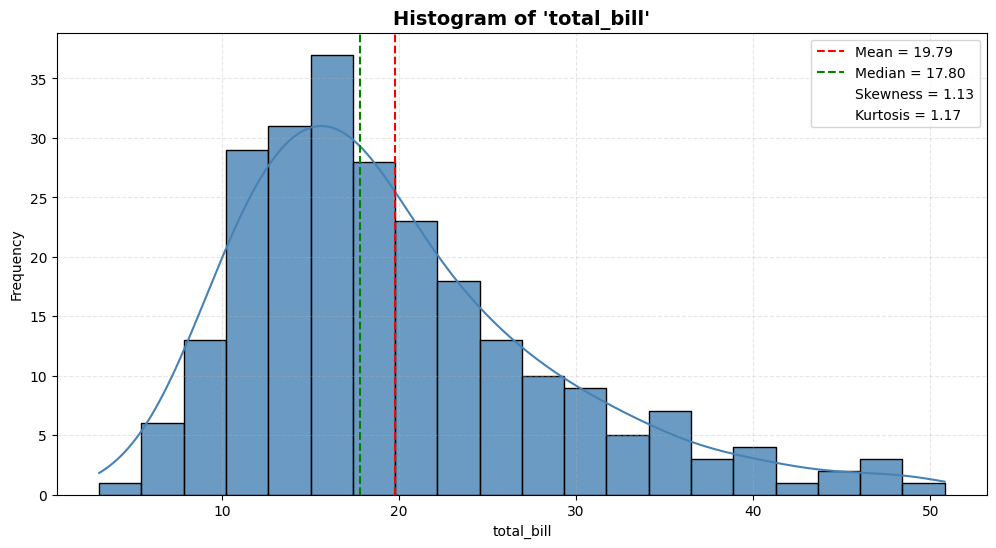

📊 Summary Statistics for 'total_bill':
   └── Mean     : 19.79
   └── Median   : 17.80
   └── Skewness : 1.13 → High positive skew (right-skewed)
   └── Kurtosis : 1.17 → Mesokurtic (normal-like)


In [81]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_histogram(df, "total_bill", bins=20, kde=True)

---
---
## **└─ (N) Boxplot**

- A Boxplot visualizes the distribution of a numerical variable through five key summary statistics:
  - Minimum (excluding outliers)
  - 1st Quartile (Q1)
  - Median (Q2)
  - 3rd Quartile (Q3)
  - Maximum (excluding outliers)

- It also highlights outliers as individual points beyond the whiskers (typically 1.5×IQR from Q1 or Q3).

**✅ When to Use:**

- To summarize and compare distributions across categories.
- Great for identifying: Skewness (asymmetry), Outliers, and Spread (IQR).
- Use in bivariate analysis to compare a numeric feature across a categorical feature.
- Excellent in side-by-side comparisons (e.g., income by gender, test scores by region).

**❌ When Not to Use:**

- When the sample size is very small (can misrepresent distribution).
- When you need to see the full shape of the distribution (use histogram/KDE or violin instead).
- For categorical or binary variables — not appropriate.

**⚠️ Tip**

- Boxplots are robust to outliers and give a quick summary of distribution and variation.
- Combine with violin plots for richer visualization of density and shape.

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_boxplot(df, feature, color="salmon", title=None):
    """
    Plot a horizontal boxplot for a numerical feature with summary statistics and outlier analysis.

    Features:
    - Horizontal boxplot with mean and median lines.
    - Displays outlier count using IQR method.
    - Prints descriptive statistics, including min, max, skewness, and kurtosis with interpretation.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Numerical column to analyze.
        color (str): Color of the box (default: 'salmon').
        title (str): Optional plot title.

    Returns:
        None. Displays the boxplot and prints summary statistics.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    if not pd.api.types.is_numeric_dtype(df[feature]):
        print(f"❌ Column '{feature}' is not numeric.")
        return

    data = df[feature].dropna()

    # Summary Stats
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    min_val = data.min()
    max_val = data.max()
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    num_outliers = outliers.count()

    mean = data.mean()
    median = data.median()
    sk = skew(data)
    kt = kurtosis(data, fisher=True)

    # Plot
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=data, color=color, width=0.3)

    plt.axvline(mean, color='red', linestyle='--', label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='green', linestyle='-', label=f"Median = {median:.2f}")
    plt.plot([], [], ' ', label=f"Skewness = {sk:.2f}")
    plt.plot([], [], ' ', label=f"Kurtosis = {kt:.2f}")
    plt.plot([], [], ' ', label=f"Outliers = {num_outliers}")

    plt.title(title or f"Boxplot of '{feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(feature)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"📊 Summary Statistics for '{feature}':")
    print(f"   └── Min      : {min_val:.2f}")
    print(f"   └── Q1       : {q1:.2f}")
    print(f"   └── Mean     : {mean:.2f}")
    print(f"   └── Median   : {median:.2f}")
    print(f"   └── Q3       : {q3:.2f}")
    print(f"   └── Max      : {max_val:.2f}")
    print(f"   └── IQR      : {iqr:.2f}")
    print(f"   └── Outliers : {num_outliers}")

    print(f"   └── Skewness : {sk:.2f} → ", end="")
    if sk > 1:
        print("High positive skew (right-skewed)")
    elif sk < -1:
        print("High negative skew (left-skewed)")
    elif abs(sk) <= 0.5:
        print("Approximately symmetric")
    else:
        print("Moderate skew")

    print(f"   └── Kurtosis : {kt:.2f} → ", end="")
    if kt > 3:
        print("Leptokurtic (peaked, heavy tails)")
    elif kt < 0:
        print("Platykurtic (flat, light tails)")
    else:
        print("Mesokurtic (normal-like)")

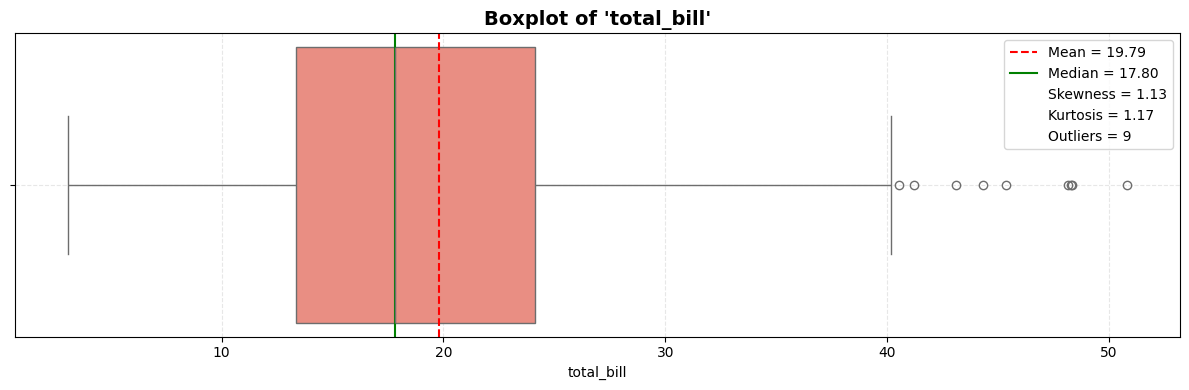

📊 Summary Statistics for 'total_bill':
   └── Min      : 3.07
   └── Q1       : 13.35
   └── Mean     : 19.79
   └── Median   : 17.80
   └── Q3       : 24.13
   └── Max      : 50.81
   └── IQR      : 10.78
   └── Outliers : 9
   └── Skewness : 1.13 → High positive skew (right-skewed)
   └── Kurtosis : 1.17 → Mesokurtic (normal-like)


In [99]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_boxplot(df, "total_bill")

---
---
## **└─ (N) Violin Plot**

- A Violin Plot combines a boxplot and a kernel density estimate (KDE). It shows:

  - The median and interquartile range (via an internal boxplot), and
  - The distribution shape (via the mirrored KDE on each side).

- This gives you both summary statistics and the underlying distribution in a single plot.

**✅ When to Use:**

- When you want to compare distributions across categories with insight into: Central tendency (mean/median), Spread (IQR), Skewness, Peaks (multi-modality), Density.
- Great for medium-to-large datasets.
- Use when shape matters (e.g., to detect bimodality or long tails).

**❌ When Not to Use:**

- With small datasets, the KDE can be misleading or noisy.
- When audience unfamiliar with violin plots may misinterpret density as volume or probability.
- Avoid if you're only interested in summary stats (boxplot is simpler).

**⚠️ Tip**

- If you're comparing groups and want to visualize distribution + outliers + symmetry, violin plots outperform boxplots.
- Combine with strip or swarm plots to show individual points inside the violins for more granularity.

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_violinplot(df, feature, color="mediumseagreen", title=None):
    """
    Plot a horizontal violin plot for a numerical feature with summary statistics and outlier analysis.

    Features:
    - Horizontal violin plot showing distribution shape and density.
    - Displays outlier count using IQR method.
    - Prints descriptive statistics, including min, max, skewness, and kurtosis with interpretation.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Numerical column to analyze.
        color (str): Color of the violin plot (default: 'mediumseagreen').
        title (str): Optional plot title.

    Returns:
        None. Displays the violin plot and prints summary statistics.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    if not pd.api.types.is_numeric_dtype(df[feature]):
        print(f"❌ Column '{feature}' is not numeric.")
        return

    data = df[feature].dropna()

    # Summary Stats
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    min_val = data.min()
    max_val = data.max()
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    num_outliers = outliers.count()

    mean = data.mean()
    median = data.median()
    sk = skew(data)
    kt = kurtosis(data, fisher=True)

    # Plot
    plt.figure(figsize=(12, 4))
    sns.violinplot(x=data, color=color, inner='box', bw_method=0.3) 

    plt.axvline(mean, color='red', linestyle='--', label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='green', linestyle='-', label=f"Median = {median:.2f}")
    plt.plot([], [], ' ', label=f"Skewness = {sk:.2f}")
    plt.plot([], [], ' ', label=f"Kurtosis = {kt:.2f}")
    plt.plot([], [], ' ', label=f"Outliers = {num_outliers}")

    plt.title(title or f"Violin Plot of '{feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(feature)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"📊 Summary Statistics for '{feature}':")
    print(f"   └── Min      : {min_val:.2f}")
    print(f"   └── Q1       : {q1:.2f}")
    print(f"   └── Mean     : {mean:.2f}")
    print(f"   └── Median   : {median:.2f}")
    print(f"   └── Q3       : {q3:.2f}")
    print(f"   └── Max      : {max_val:.2f}")
    print(f"   └── IQR      : {iqr:.2f}")
    print(f"   └── Outliers : {num_outliers}")

    print(f"   └── Skewness : {sk:.2f} → ", end="")
    if sk > 1:
        print("High positive skew (right-skewed)")
    elif sk < -1:
        print("High negative skew (left-skewed)")
    elif abs(sk) <= 0.5:
        print("Approximately symmetric")
    else:
        print("Moderate skew")

    print(f"   └── Kurtosis : {kt:.2f} → ", end="")
    if kt > 3:
        print("Leptokurtic (peaked, heavy tails)")
    elif kt < 0:
        print("Platykurtic (flat, light tails)")
    else:
        print("Mesokurtic (normal-like)")

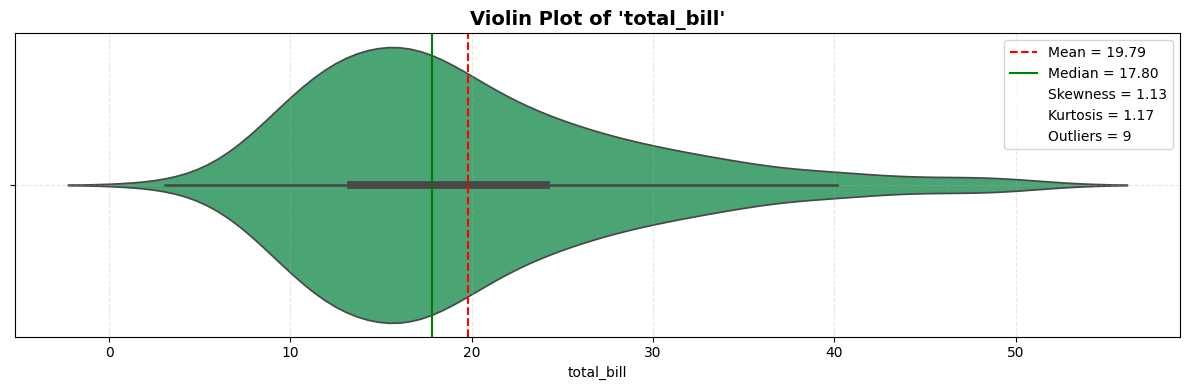

📊 Summary Statistics for 'total_bill':
   └── Min      : 3.07
   └── Q1       : 13.35
   └── Mean     : 19.79
   └── Median   : 17.80
   └── Q3       : 24.13
   └── Max      : 50.81
   └── IQR      : 10.78
   └── Outliers : 9
   └── Skewness : 1.13 → High positive skew (right-skewed)
   └── Kurtosis : 1.17 → Mesokurtic (normal-like)


In [107]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_violinplot(df, "total_bill")

---
---
## **└─ (N) QQ Plot**

- A Q-Q plot compares the quantiles of your dataset’s distribution with the quantiles of a theoretical distribution — most commonly, the normal distribution.
- If your data follows the theoretical distribution (e.g. normal), the points will lie approximately on the straight diagonal line.
- Deviations from the line indicate skewness, heavy tails, or non-normality.

**✅ When to Use:**

- To assess normality of a variable visually (e.g., before applying parametric tests like t-tests or linear regression).
- When checking for distributional assumptions in modeling.
- As a complement to statistical normality tests (e.g., Shapiro-Wilk, Kolmogorov-Smirnov).

**❌ When Not to Use:**

- When you only need summary statistics (mean, median, std) — it’s better for visual shape comparison.
- Not suitable for categorical data.
- For large datasets, overplotting may obscure interpretation — consider sampling.

**⚠️ Tip**

- If the tails curve away from the line, your data may have heavy/light tails (i.e., leptokurtic or platykurtic).
- If the points curve upward/downward, your data may be right-/left-skewed.

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import skew, kurtosis

def plot_qqplot(df, feature, title=None):
    """
    Plot a QQ plot for a numerical feature with summary statistics and distribution interpretation.

    Features:
    - QQ plot comparing feature distribution to normal distribution.
    - Prints mean, median, min, max, skewness, kurtosis with interpretation.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Numerical column to analyze.
        title (str): Optional plot title.

    Returns:
        None. Displays QQ plot and prints summary stats.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    if not pd.api.types.is_numeric_dtype(df[feature]):
        print(f"❌ Column '{feature}' is not numeric.")
        return

    data = df[feature].dropna()

    mean = data.mean()
    median = data.median()
    min_val = data.min()
    max_val = data.max()
    sk = skew(data)
    kt = kurtosis(data, fisher=True)

    plt.figure(figsize=(8, 6))
    sm.qqplot(data, line='s', markerfacecolor='blue', markeredgecolor='black', alpha=0.7)
    plt.title(title or f"QQ Plot of '{feature}'", fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"📊 Summary Statistics for '{feature}':")
    print(f"   └── Mean     : {mean:.2f}")
    print(f"   └── Median   : {median:.2f}")
    print(f"   └── Min      : {min_val:.2f}")
    print(f"   └── Max      : {max_val:.2f}")
    print(f"   └── Skewness : {sk:.2f} → ", end="")
    if sk > 1:
        print("High positive skew (right-skewed)")
    elif sk < -1:
        print("High negative skew (left-skewed)")
    elif abs(sk) <= 0.5:
        print("Approximately symmetric")
    else:
        print("Moderate skew")
    print(f"   └── Kurtosis : {kt:.2f} → ", end="")
    if kt > 3:
        print("Leptokurtic (peaked, heavy tails)")
    elif kt < 0:
        print("Platykurtic (flat, light tails)")
    else:
        print("Mesokurtic (normal-like)")

<Figure size 800x600 with 0 Axes>

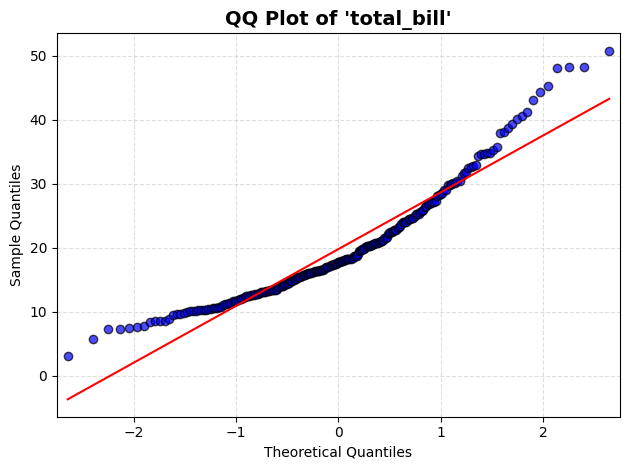

📊 Summary Statistics for 'total_bill':
   └── Mean     : 19.79
   └── Median   : 17.80
   └── Min      : 3.07
   └── Max      : 50.81
   └── Skewness : 1.13 → High positive skew (right-skewed)
   └── Kurtosis : 1.17 → Mesokurtic (normal-like)


In [117]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_qqplot(df, "total_bill")

---
---
## **└─ (C) Count Plot**

- A Count Plot is a bar chart that displays the number of occurrences (frequency) of each category in a categorical variable. It is essentially a visual summary of value_counts().
- Built on top of bar plots, but counts the number of rows per category automatically.
- Implemented in Seaborn as sns.countplot().

**✅ When to Use:**

- To visualize the distribution of a single categorical variable.
- To quickly identify the most or least common categories.
- To compare counts across different groups using the hue parameter.
- For class balance checks (e.g., in binary classification: subscribed vs not subscribed).

**❌ When Not to Use:**

- For numerical data (use histogram instead).
- When you want to show percentages or proportions — use a pie chart or normalized bar plot instead.
- If there are too many unique categories, the plot can become cluttered and unreadable.

**⚠️ Tip**

- Use hue= to break down each bar by another category (e.g., gender by smoker).
- Rotate x-axis labels (plt.xticks(rotation=45)) if categories overlap.
- Count plots are ideal for EDA and reporting, especially for class imbalance checks in ML.

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_countplot(df, feature, top_n=10, color='steelblue', title=None):
    """
    Plot a vertical count plot for a categorical feature showing frequency counts and percentages.

    Features:
    - Vertical count plot showing counts of top categories (others grouped).
    - Prints frequency table with counts and percentages.
    - Handles missing values by excluding them from plot but reports count.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Categorical column to analyze.
        top_n (int): Number of top categories to show (default: 10).
        color (str): Bar color (default: 'steelblue').
        title (str): Optional plot title.

    Returns:
        None. Displays count plot and prints frequency stats.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    if not (isinstance(df[feature].dtype, pd.CategoricalDtype) or df[feature].dtype == 'object'):
        print(f"❌ Column '{feature}' is not categorical.")
        return

    data = df[feature].dropna()

    # Frequency counts
    counts = data.value_counts()
    
    # Group 'Others' if more categories than top_n
    if len(counts) > top_n:
        top_categories = counts.index[:top_n].tolist()
        # Create a new column with 'Others' grouping
        df_copy = df.copy()
        df_copy['plot_cat'] = df_copy[feature].where(df_copy[feature].isin(top_categories), other='Others')
        plot_order = top_categories + ['Others']
    else:
        df_copy = df.copy()
        df_copy['plot_cat'] = df_copy[feature]
        plot_order = counts.index.tolist()

    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_copy, x='plot_cat', order=plot_order, color=color)
    plt.title(title or f"Count Plot of '{feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Report missing values if any
    missing_count = df[feature].isnull().sum()
    total_rows = len(df)
    if missing_count > 0:
        print(f"⚠️ Missing values: {missing_count} out of {total_rows} rows ({missing_count/total_rows*100:.2f}%)")

    # Frequency table for the grouped data
    freq_counts = df_copy['plot_cat'].value_counts()
    freq_table = pd.DataFrame({
        'Count': freq_counts,
        'Percentage (%)': (freq_counts / freq_counts.sum() * 100).round(2)
    }).loc[plot_order]
    display(freq_table)

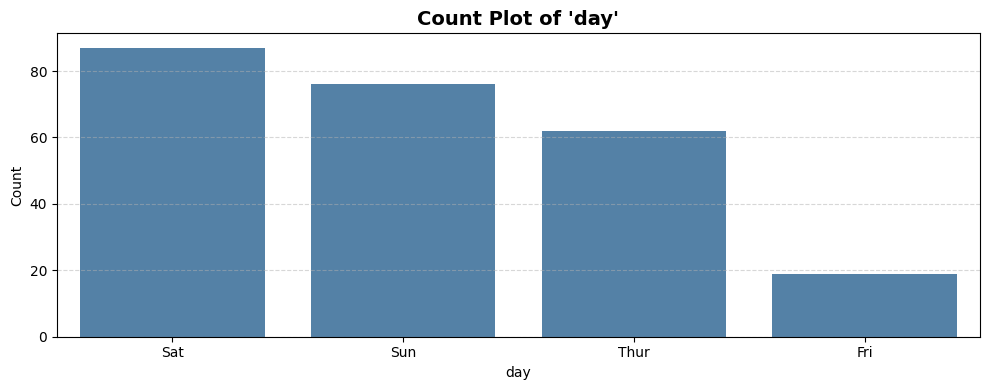

,Count,Percentage (%)
plot_cat,,
Sat,87,35.66
Sun,76,31.15
Thur,62,25.41
Fri,19,7.79


In [138]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_countplot(df, "day")

---
---
## **└─ (C) Pie Chart**

- A Pie Chart is a circular statistical graphic that shows the proportional composition of a categorical variable.
- Each slice represents a category's share of the total, expressed in percentages or fractions.
- Ideal for visualizing the relative size of each group in a whole.
- Labels and percentages can enhance clarity.

**✅ When to Use:**

- To show part-to-whole relationships.
- When you have a few (≤5–6) distinct categories.
- To emphasize dominance or contribution of one or two groups.

**❌ When Not to Use:**

- When there are many categories — it becomes cluttered and unreadable.
- If precise comparison between categories is needed — use a bar chart instead.
- When proportions are very similar — differences are hard to distinguish visually.

**⚠️ Tip**

- Always annotate slices with percentages or category labels.
- Use contrasting colors to distinguish slices.
- Consider using a donut chart for a cleaner and more modern look.
- Avoid 3D pie charts — they distort perception and add no value.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_pie_chart(df, feature, top_n=5, title=None, colors=None):
    """
    Plot a pie chart for a categorical feature with top categories and "Others".

    Features:
    - Pie chart of top_n categories by count.
    - Remaining categories grouped as "Others".
    - Shows percentages and counts on slices.
    - Handles missing values by excluding them.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature (str): Categorical column to analyze.
        top_n (int): Number of top categories to show (default: 5).
        title (str): Optional plot title.
        colors (list or None): Optional list of colors for slices.

    Returns:
        None. Displays the pie chart and prints frequency table.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return
    
    if not (isinstance(df[feature].dtype, pd.CategoricalDtype) or df[feature].dtype == 'object'):
        print(f"❌ Column '{feature}' is not categorical.")
        return

    data = df[feature].dropna()

    counts = data.value_counts()
    if len(counts) > top_n:
        top_counts = counts[:top_n]
        others_count = counts[top_n:].sum()
        pie_counts = top_counts.append(pd.Series({'Others': others_count}))
    else:
        pie_counts = counts

    # Colors
    if colors is None:
        colors = plt.get_cmap('tab20').colors[:len(pie_counts)]

    plt.figure(figsize=(5, 5))
    wedges, texts, autotexts = plt.pie(
        pie_counts,
        labels=pie_counts.index,
        autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100*pie_counts.sum())})",
        startangle=90,
        colors=colors,
        textprops={'fontsize': 11}
    )
    plt.title(title or f"Pie Chart of '{feature}'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print frequency table
    freq_table = pd.DataFrame({
        'Count': pie_counts,
        'Percentage (%)': (pie_counts / pie_counts.sum() * 100).round(2)
    })
    display(freq_table)

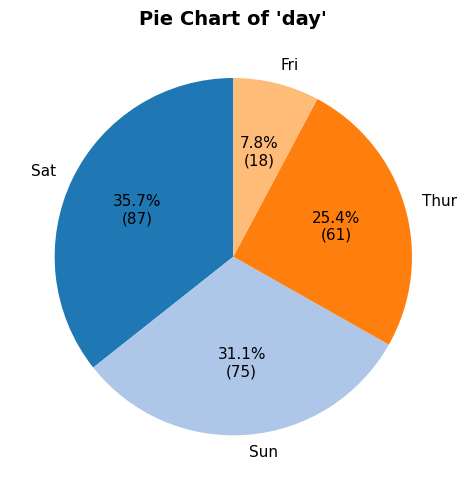

,Count,Percentage (%)
day,,
Sat,87,35.66
Sun,76,31.15
Thur,62,25.41
Fri,19,7.79


In [149]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_pie_chart(df, "day")

---
---
## **└─ (C) Treemap**

- A Treemap is a space-filling chart that represents hierarchical or categorical data using nested rectangles.
- The size and optionally the color of each rectangle correspond to a numerical value, typically frequency or proportion.

**✅ When to Use:**

- When you want to show part-to-whole relationships in a compact way.
- When you have many categories or sub-categories and want to show both size and hierarchy.
- To compare multiple categories by area when labels might not fit a bar or pie chart.

**❌ When Not to Use:**

- When precise comparison between values is needed — a bar chart is better.
- If all rectangles are nearly equal in size — harder to visually differentiate.

**⚠️ Tip**

- Keep labels readable — show category + percentage inside larger blocks.
- Use categorical palettes (Set3, Pastel1) or sequential palettes (Blues, viridis) depending on the data context.
- Limit the number of categories (ideally under 15) to avoid visual clutter.
- Consider grouping smaller segments into an "Others" category.
- Treemaps work great in dashboards for compact summary insights.

In [229]:
import matplotlib.pyplot as plt
import squarify
import pandas as pd

def plot_treemap(df, feature, title=None, cmap='Spectral'):
    """
    Plot a treemap showing the relative size of categories in a categorical feature.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        feature (str): Categorical column to plot.
        title (str): Optional title.
        cmap (str): Matplotlib colormap for coloring blocks.

    Returns:
        None. Displays the treemap.
    """
    if feature not in df.columns:
        print(f"❌ Column '{feature}' not found.")
        return

    counts = df[feature].value_counts()
    labels = counts.index.tolist()
    sizes = counts.values

    # Normalize sizes for squarify (optional)
    sizes = sizes / sizes.sum() * 100

    # Colors from colormap
    cmap = plt.get_cmap(cmap)
    colors = [cmap(i / len(sizes)) for i in range(len(sizes))]

    plt.figure(figsize=(12, 7))
    squarify.plot(sizes=sizes, label=[f"{lab}\n{val}" for lab, val in zip(labels, counts)],
                  color=colors, alpha=0.8, edgecolor='white', linewidth=2)

    plt.axis('off')
    plt.title(title or f"Treemap of '{feature}'", fontsize=16, fontweight='bold')
    plt.show()

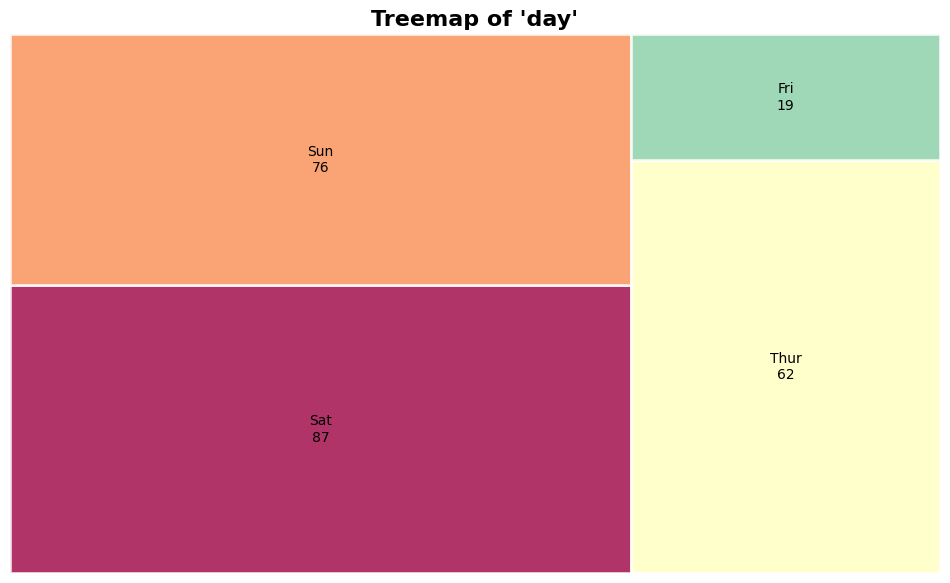

In [230]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_treemap(df, "day")

---
---
---
# **🟠 Bivariate Plots**

| Variable Pair Type             | Plot Types                                                                     |
| ------------------------------ | ------------------------------------------------------------------------------ |
| **Numerical vs Numerical**     | Scatter Plot, Regression Line, Hexbin Plot, Residual Plot, Correlation Heatmap |
| **Categorical vs Numerical**   | Boxplot, Violin Plot, Strip Plot, Bar Plot (with Mean/Median), Swarmplot       |
| **Categorical vs Categorical** | Clustered Bar Chart, Stacked Bar Chart, Mosaic Plot, Heatmap, Treemap          |

---
---
## **└─ (NN) Scatter Plot + Regression Line**

- A Scatter Plot displays the relationship between two numerical variables using points.
- Adding a regression line (usually linear) helps reveal the direction, strength, and form of the relationship between the variables.

**✅ When to Use:**

- To visualize correlations or patterns between two continuous variables (e.g., height vs. weight).
- When you want to model trends or fit a predictive line (e.g., linear regression).
- To identify outliers and clusters in your data.

**❌ When Not to Use:**

- When either variable is categorical — use bar, box, or violin plots instead.
- If data is highly non-linear and a linear regression would mislead.
- For very large datasets where overplotting may occur — consider a hexbin or density plot.

**⚠️ Tip**

- Use hue or color to represent a third categorical feature for multi-group comparison.
- Add confidence intervals (e.g., using sns.regplot in Seaborn) to show uncertainty around the trend line.
- Use scatter transparency (alpha) to handle overplotting.
- For non-linear relationships, consider polynomial or LOESS smoothing instead of linear fits.

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter(df, x_feature, y_feature, hue=None, title=None, palette='deep', figsize=(10,6)):
    """
    Plot a scatter plot for two numerical features with optional hue (categorical color grouping).

    Features:
    - Scatter plot of x vs y.
    - Optional color grouping by a categorical variable (hue).
    - Optionally shows regression line if hue is None.
    - Displays axis labels and title.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Name of numeric feature for x-axis.
        y_feature (str): Name of numeric feature for y-axis.
        hue (str or None): Optional categorical column for color grouping.
        title (str): Optional plot title.
        palette (str or list): Color palette for hue groups.
        figsize (tuple): Figure size.

    Returns:
        None. Displays the scatter plot.
    """
    # Checks
    for feature in [x_feature, y_feature]:
        if feature not in df.columns:
            print(f"❌ Column '{feature}' not found.")
            return
        if not pd.api.types.is_numeric_dtype(df[feature]):
            print(f"❌ Column '{feature}' is not numeric.")
            return

    if hue:
        if hue not in df.columns:
            print(f"❌ Hue column '{hue}' not found.")
            return
        if not (isinstance(df[hue].dtype, pd.CategoricalDtype) or df[hue].dtype == 'object'):
            print(f"❌ Hue column '{hue}' is not categorical.")
            return

    plt.figure(figsize=figsize)

    if hue:
        sns.scatterplot(data=df, x=x_feature, y=y_feature, hue=hue, palette=palette, alpha=0.7)
    else:
        sns.regplot(data=df, x=x_feature, y=y_feature, scatter_kws={'alpha':0.7}, line_kws={'color':'red'})

    plt.title(title or f"Scatter Plot of {y_feature} vs {x_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

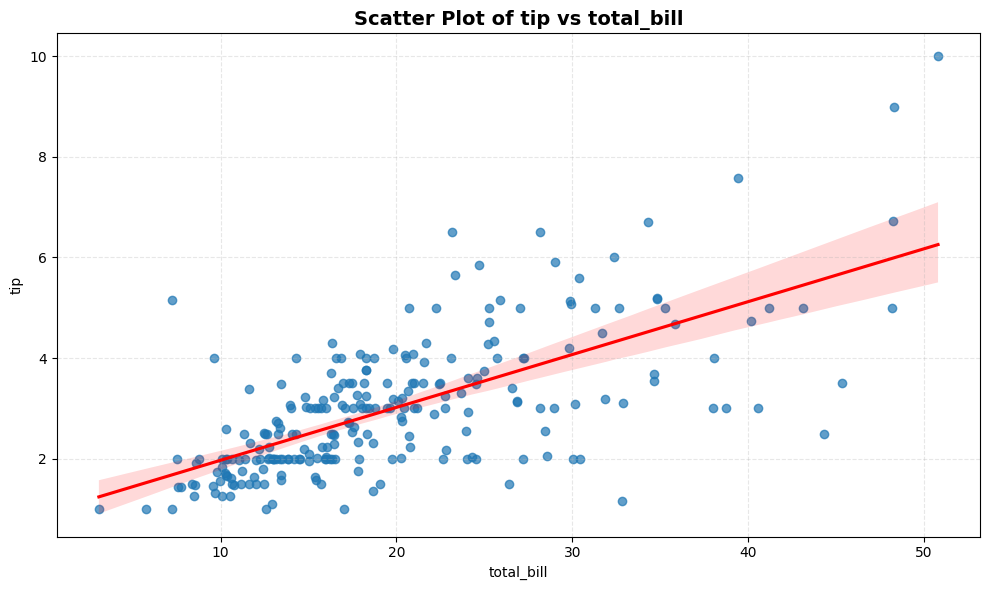

In [157]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_scatter(df, "total_bill", "tip")

---
---
## **└─ (NN) Hexbin Plot**

- A Hexbin plot is a bivariate visualization that displays the relationship between two continuous variables by dividing the plane into hexagonal bins.
- The color intensity of each hexagon represents the count or density of points falling within that bin, helping to visualize point concentration and distribution.

**✅ When to Use:**

- When you have large datasets with many overlapping points causing overplotting in scatter plots.
- To reveal density patterns and clusters in the joint distribution of two numerical variables.
- When you want a clearer picture of data concentration in 2D space.

**❌ When Not to Use:**

- For small datasets where individual points are important.
- When exact point positions and values matter more than overall density.
- If the data is categorical or mixed types (use other plots instead).

**⚠️ Tip**

- Adjust gridsize to control hexagon size — smaller grids for more detail, larger for smoother density.
- Use sequential or diverging color palettes (e.g., viridis, plasma) for intuitive interpretation.
- Include a colorbar to indicate counts or density values.
- Combine with marginal histograms or KDE plots for deeper analysis.

In [158]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hexbin(df, x_feature, y_feature, gridsize=30, cmap='Blues', mincnt=1, title=None, figsize=(10,6)):
    """
    Plot a hexbin plot for two numerical features to visualize point density.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Name of numeric feature for x-axis.
        y_feature (str): Name of numeric feature for y-axis.
        gridsize (int): Number of hexagons in the x-direction (default: 30).
        cmap (str): Colormap for hexagons (default: 'Blues').
        mincnt (int): Minimum count in a hexagon to be colored (default: 1).
        title (str): Optional plot title.
        figsize (tuple): Figure size.

    Returns:
        None. Displays the hexbin plot.
    """
    # Check columns existence and numeric type
    for feat in [x_feature, y_feature]:
        if feat not in df.columns:
            print(f"❌ Column '{feat}' not found.")
            return
        if not pd.api.types.is_numeric_dtype(df[feat]):
            print(f"❌ Column '{feat}' is not numeric.")
            return

    plt.figure(figsize=figsize)
    hb = plt.hexbin(df[x_feature], df[y_feature], gridsize=gridsize, cmap=cmap, mincnt=mincnt, edgecolors='gray', linewidths=0.2)
    plt.colorbar(hb, label='Count in bin')

    plt.title(title or f"Hexbin Plot of {y_feature} vs {x_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

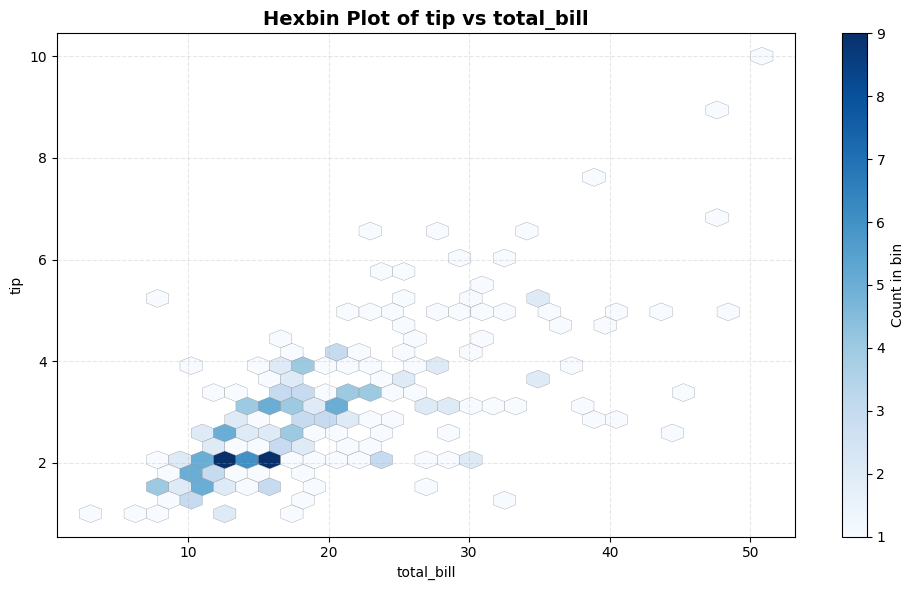

In [159]:
# Load example
import seaborn as sns
df = sns.load_dataset("tips")

plot_hexbin(df, "total_bill", "tip")

---
---
## **└─ (NN) Residual Plot**

- A Residual Plot visualizes the residuals (errors) of a regression model, plotting the difference between observed and predicted values against the predicted values or an independent variable.
- It helps assess the goodness of fit and detect patterns in residuals that indicate model issues.

**✅ When to Use:**

- To check if a regression model meets assumptions like linearity, homoscedasticity (constant variance), and independence of errors.
- To identify non-linear relationships, outliers, or heteroscedasticity (changing variance).
- During model diagnostics to improve or validate predictive models.

**❌ When Not to Use:**

- When you have no regression or predictive model fitted.
- For purely exploratory data analysis without a fitted model.
- When residuals are not defined (e.g., classification tasks without probability outputs).

**⚠️ Tip**

- Residuals should be randomly scattered around zero without obvious patterns.
- A funnel shape or systematic curve in residuals indicates problems with the model.
- Use alongside other diagnostics like Q-Q plots or leverage plots for comprehensive assessment.
- Plot standardized or studentized residuals for better comparability.

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

def plot_residuals(df, predictor, target, color='teal', title=None):
    """
    Fit a simple linear regression model using `predictor` to predict `target`.
    Plot residuals vs predicted values.

    Parameters:
        df (pd.DataFrame): Dataset containing the variables.
        predictor (str): Name of predictor feature column.
        target (str): Name of target (dependent) variable column.
        color (str): Color of residual points.
        title (str): Optional plot title.

    Returns:
        None. Displays residual plot and prints residual summary statistics.
    """
    # Check columns exist
    if predictor not in df.columns:
        print(f"❌ Predictor '{predictor}' not found.")
        return
    if target not in df.columns:
        print(f"❌ Target '{target}' not found.")
        return

    # Check numeric dtype
    if not pd.api.types.is_numeric_dtype(df[predictor]):
        print(f"❌ Predictor '{predictor}' is not numeric.")
        return
    if not pd.api.types.is_numeric_dtype(df[target]):
        print(f"❌ Target '{target}' is not numeric.")
        return

    # Drop NA rows for these columns
    data = df[[predictor, target]].dropna()
    X = data[[predictor]].values
    y_true = data[target].values

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y_true)
    y_pred = model.predict(X)

    # Residuals
    residuals = y_true - y_pred

    # Plot residuals vs predicted
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=y_pred, y=residuals, color=color, edgecolor='k', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', label='Zero Residual Line')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals (True - Predicted)')
    plt.title(title or f"Residual Plot: {target} ~ {predictor}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print residual stats
    print(f"Residuals summary:")
    print(f"  Mean residual       : {np.mean(residuals):.4f}")
    print(f"  Residual std dev    : {np.std(residuals):.4f}")
    print(f"  Residual min        : {np.min(residuals):.4f}")
    print(f"  Residual max        : {np.max(residuals):.4f}")

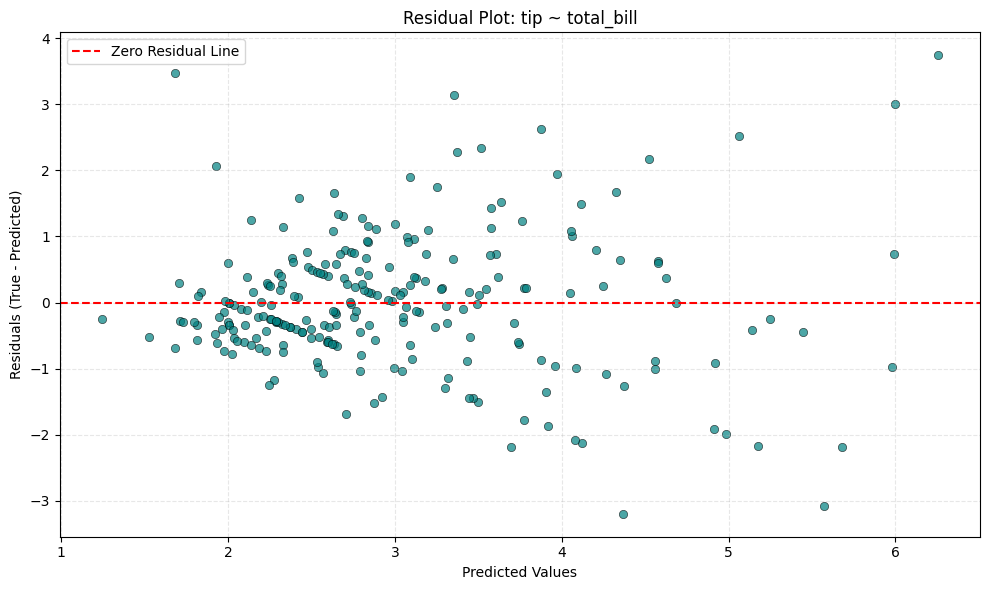

Residuals summary:
  Mean residual       : 0.0000
  Residual std dev    : 1.0179
  Residual min        : -3.1982
  Residual max        : 3.7434


In [165]:
import seaborn as sns
df = sns.load_dataset('tips')

plot_residuals(df, predictor='total_bill', target='tip')

---
---
## **└─ (NN) Correlation Heatmap**

- A Correlation Heatmap is a graphical representation of a correlation matrix, where colors encode the strength and direction of relationships between numerical variables.
- It provides a quick visual overview of how variables are related, highlighting strong positive, negative, or no correlations.

**✅ When to Use:**

- To explore and summarize relationships among multiple continuous variables.
- To identify highly correlated variables for feature selection or multicollinearity checks.
- When preparing data for modeling to understand variable interactions.

**❌ When Not to Use:**

- For categorical variables without numeric encoding.
- When the dataset is too large and the heatmap becomes cluttered and hard to interpret.
- When detailed causal analysis is required—correlation does not imply causation.

**⚠️ Tip**

- Use diverging color palettes (e.g., coolwarm, RdBu) to distinguish positive and negative correlations clearly.
- Annotate cells with correlation coefficients for precise interpretation.
- Apply hierarchical clustering or reorder variables to reveal patterns or clusters.
- Always complement with scatterplots or other analyses to confirm relationships.

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(df, x_feature, y_feature, annot=True, cmap='coolwarm', fmt=".2f", title=None, figsize=(8,6)):
    """
    Plot a heatmap showing correlation between two numerical features.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Name of first numeric feature.
        y_feature (str): Name of second numeric feature.
        annot (bool): Whether to annotate cells with correlation values (default: True).
        cmap (str): Colormap for the heatmap (default: 'coolwarm').
        fmt (str): String formatting code for annotations (default: ".2f").
        title (str): Optional plot title.
        figsize (tuple): Figure size.

    Returns:
        None. Displays the heatmap.
    """
    # Validate columns
    for feat in [x_feature, y_feature]:
        if feat not in df.columns:
            print(f"❌ Column '{feat}' not found.")
            return
        if not pd.api.types.is_numeric_dtype(df[feat]):
            print(f"❌ Column '{feat}' is not numeric.")
            return

    # Calculate correlation matrix for the two features
    corr_matrix = df[[x_feature, y_feature]].corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=annot, cmap=cmap, fmt=fmt, vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='gray')

    plt.title(title or f"Correlation Heatmap: {x_feature} & {y_feature}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

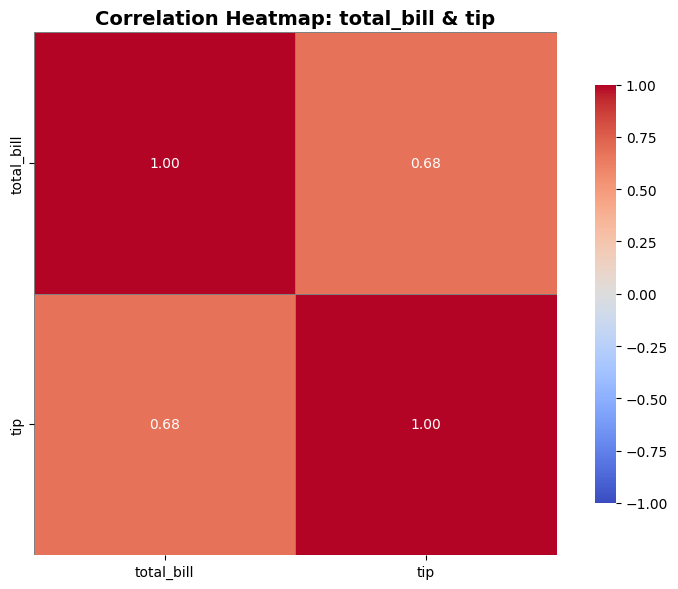

In [167]:
import seaborn as sns
df = sns.load_dataset('tips')

plot_heatmap(df, 'total_bill', 'tip')

---
---
## **└─ (CN) Boxplot**

- A Boxplot (or box-and-whisker plot) displays the distribution of a numerical variable across different categories, showing the median, interquartile range (IQR), and potential outliers.
- It's useful for comparing the spread and central tendency of a numerical feature across categorical groups.

**✅ When to Use:**

- To compare distributions of a continuous variable across multiple categories.
- To detect skewness, variability, and outliers within each group.
- During exploratory data analysis (EDA) for feature-target relationships.

**❌ When Not to Use:**

- When the categorical variable has too many levels — the plot becomes cluttered and unreadable.
- For small sample sizes in categories — statistical summaries may be misleading.
- If detailed individual point values are important — consider swarm or strip plots instead.

**⚠️ Tip**

- Overlay mean/median lines or annotate key statistics for richer insights.
- Combine with violin or strip plots for more granularity.
- Rotate x-axis labels if category names are long or overlapping.
- For large datasets, use boxplots for summary, then zoom in with histograms or scatter plots.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot_bivariate(df, cat_feature, num_feature, color="skyblue", title=None):
    """
    Plot a boxplot for bivariate analysis of a categorical and a numerical feature.

    Parameters:
        df (pd.DataFrame): Input dataset.
        cat_feature (str): Categorical column name.
        num_feature (str): Numerical column name.
        color (str): Color of the boxes (default: 'skyblue').
        title (str): Optional plot title.

    Returns:
        None. Displays the boxplot and prints summary statistics per category.
    """
    # Validate columns
    if cat_feature not in df.columns:
        print(f"❌ Column '{cat_feature}' not found.")
        return
    if num_feature not in df.columns:
        print(f"❌ Column '{num_feature}' not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[num_feature]):
        print(f"❌ '{num_feature}' is not numeric.")
        return
    if not (isinstance(df[cat_feature].dtype, pd.CategoricalDtype) or df[cat_feature].dtype == 'object'):
        print(f"❌ '{cat_feature}' is not categorical.")
        return

    # Drop NA for relevant columns
    data = df[[cat_feature, num_feature]].dropna()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=cat_feature, y=num_feature, data=data, color=color)
    plt.title(title or f"Boxplot of '{num_feature}' grouped by '{cat_feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel(num_feature)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print descriptive stats per category
    print(f"📊 Summary statistics of '{num_feature}' by '{cat_feature}':\n")
    summary = data.groupby(cat_feature, observed=False)[num_feature].describe().round(2)
    print(summary)

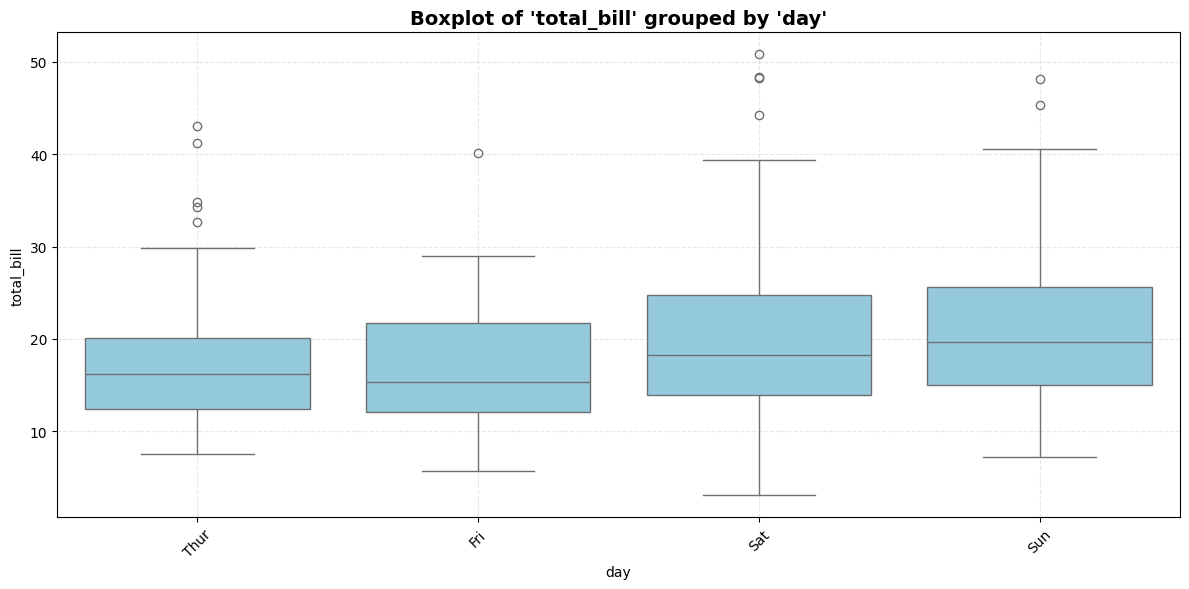

📊 Summary statistics of 'total_bill' by 'day':

      count   mean   std   min    25%    50%    75%    max
day                                                       
Thur   62.0  17.68  7.89  7.51  12.44  16.20  20.16  43.11
Fri    19.0  17.15  8.30  5.75  12.10  15.38  21.75  40.17
Sat    87.0  20.44  9.48  3.07  13.90  18.24  24.74  50.81
Sun    76.0  21.41  8.83  7.25  14.99  19.63  25.60  48.17


In [177]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_boxplot_bivariate(df, cat_feature='day', num_feature='total_bill')

---
---
## **└─ (CN) Violin Plot**

- A Violin Plot combines a boxplot and a kernel density estimate (KDE). It shows:

  - The median and interquartile range (via an internal boxplot), and
  - The distribution shape (via the mirrored KDE on each side).

- This gives you both summary statistics and the underlying distribution in a single plot.

**✅ When to Use:**

- When you want to compare distributions across categories with insight into: Central tendency (mean/median), Spread (IQR), Skewness, Peaks (multi-modality), Density.
- Great for medium-to-large datasets.
- Use when shape matters (e.g., to detect bimodality or long tails).

**❌ When Not to Use:**

- With small datasets, the KDE can be misleading or noisy.
- When audience unfamiliar with violin plots may misinterpret density as volume or probability.
- Avoid if you're only interested in summary stats (boxplot is simpler).

**⚠️ Tip**

- If you're comparing groups and want to visualize distribution + outliers + symmetry, violin plots outperform boxplots.
- Combine with strip or swarm plots to show individual points inside the violins for more granularity.

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_violinplot_bivariate(df, cat_feature, num_feature, color="mediumseagreen", title=None):
    """
    Plot a violin plot for numerical feature grouped by categorical feature,
    with printed descriptive stats per category.

    Parameters:
        df (pd.DataFrame): Input dataframe.
        cat_feature (str): Categorical column name.
        num_feature (str): Numerical column name.
        color (str): Violin plot color (default: mediumseagreen).
        title (str): Optional plot title.

    Returns:
        None. Displays violin plot and prints summary statistics.
    """
    # Validate columns
    if cat_feature not in df.columns:
        print(f"❌ Column '{cat_feature}' not found.")
        return
    if num_feature not in df.columns:
        print(f"❌ Column '{num_feature}' not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[num_feature]):
        print(f"❌ '{num_feature}' is not numeric.")
        return

    data = df[[cat_feature, num_feature]].dropna()

    plt.figure(figsize=(12, 6))
    sns.violinplot(x=cat_feature, y=num_feature, data=data, color=color)
    plt.title(title or f"Violin plot of '{num_feature}' by '{cat_feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel(num_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print descriptive stats per category
    print(f"📊 Summary stats of '{num_feature}' by '{cat_feature}':\n")
    grouped = data.groupby(cat_feature, observed=False)[num_feature]
    summary_df = grouped.agg(['count', 'mean', 'median', 'std', skew, kurtosis]).round(2)
    summary_df.rename(columns={'count': 'Count', 'mean': 'Mean', 'median': 'Median',
                               'std': 'StdDev', 'skew': 'Skewness', 'kurtosis': 'Kurtosis'}, inplace=True)
    print(summary_df)

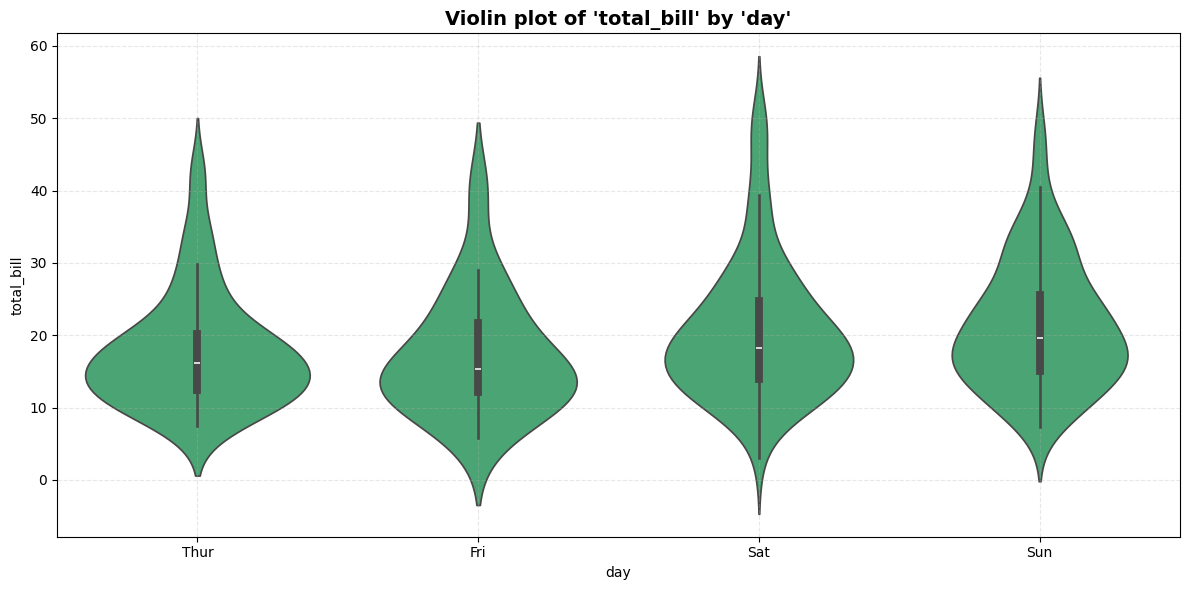

📊 Summary stats of 'total_bill' by 'day':
      Count   Mean  Median  StdDev  Skewness  Kurtosis
day                                                   
Thur     62  17.68   16.20    7.89      1.33      1.58
Fri      19  17.15   15.38    8.30      1.21      1.21
Sat      87  20.44   18.24    9.48      1.24      1.55
Sun      76  21.41   19.63    8.83      0.81      0.32


In [181]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_violinplot_bivariate(df, cat_feature='day', num_feature='total_bill')

---
---
## **└─ (CN) Strip Plot**

- A Strip Plot is a scatter plot where one variable is categorical and the other is numerical.
- It plots individual data points along the axis of the numerical variable, allowing you to see all observations in each category.

**✅ When to Use:**

- When you want to see all raw data points by category.
- To identify clustering, spread, and outliers in small-to-medium-sized datasets.
- As a complement to boxplots or violin plots to provide granularity.

**❌ When Not to Use:**

- For large datasets with overlapping points — use jitter or a swarm plot instead.
- When the main goal is distribution comparison — violin or boxplots may be clearer.
- When there's excessive overplotting — readability suffers.

**⚠️ Tip**

- Add jitter=True to avoid overlap and make individual points distinguishable.
- Use along with hue for a second categorical grouping.
- Combine with boxplot or violin plot for richer visual analysis.
- Be cautious of interpretation — points don’t represent density.

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_stripplot(df, cat_feature, num_feature, color="dodgerblue", jitter=True, title=None):
    """
    Plot a strip plot for numerical feature grouped by categorical feature,
    with printed descriptive stats per category.

    Parameters:
        df (pd.DataFrame): Input dataframe.
        cat_feature (str): Categorical column name.
        num_feature (str): Numerical column name.
        color (str): Marker color (default: dodgerblue).
        jitter (bool): Whether to add jitter (default: True).
        title (str): Optional plot title.

    Returns:
        None. Displays strip plot and prints summary statistics.
    """
    # Validate columns
    if cat_feature not in df.columns:
        print(f"❌ Column '{cat_feature}' not found.")
        return
    if num_feature not in df.columns:
        print(f"❌ Column '{num_feature}' not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[num_feature]):
        print(f"❌ '{num_feature}' is not numeric.")
        return

    data = df[[cat_feature, num_feature]].dropna()

    plt.figure(figsize=(12, 6))
    sns.stripplot(x=cat_feature, y=num_feature, data=data, color=color, jitter=jitter)
    plt.title(title or f"Strip plot of '{num_feature}' by '{cat_feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel(num_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print descriptive stats per category
    print(f"📊 Summary stats of '{num_feature}' by '{cat_feature}':\n")
    grouped = data.groupby(cat_feature, observed=False)[num_feature]
    summary_df = grouped.agg(['count', 'mean', 'median', 'std', skew, kurtosis]).round(2)
    summary_df.rename(columns={'count': 'Count', 'mean': 'Mean', 'median': 'Median',
                               'std': 'StdDev', 'skew': 'Skewness', 'kurtosis': 'Kurtosis'}, inplace=True)
    print(summary_df)

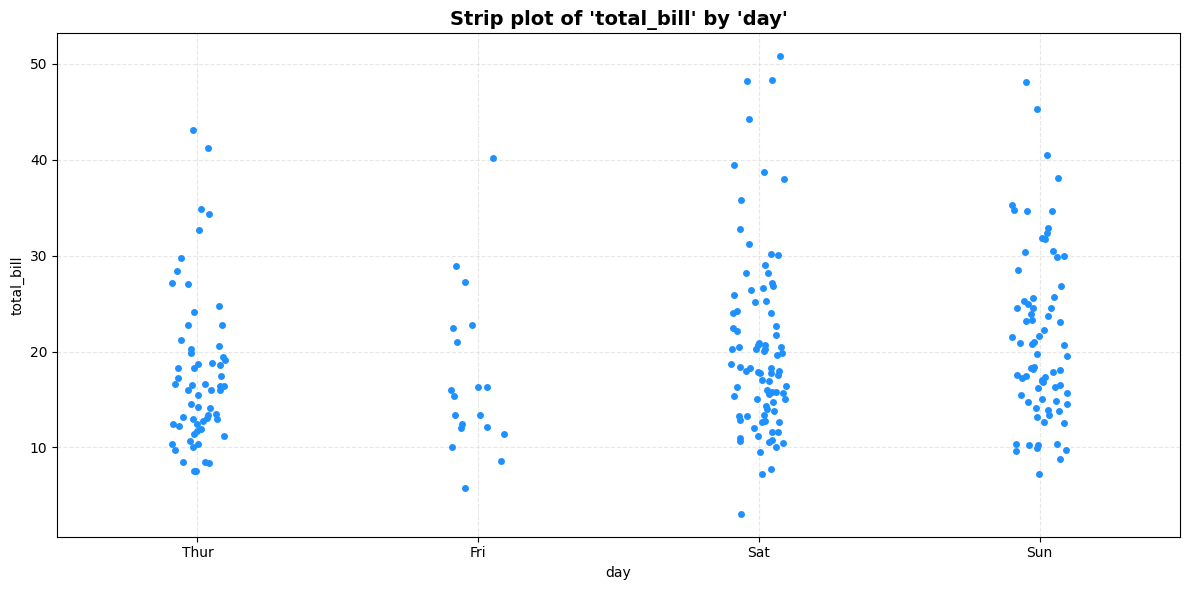

📊 Summary stats of 'total_bill' by 'day':

      Count   Mean  Median  StdDev  Skewness  Kurtosis
day                                                   
Thur     62  17.68   16.20    7.89      1.33      1.58
Fri      19  17.15   15.38    8.30      1.21      1.21
Sat      87  20.44   18.24    9.48      1.24      1.55
Sun      76  21.41   19.63    8.83      0.81      0.32


In [187]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_stripplot(df, cat_feature='day', num_feature='total_bill')

---
---
## **└─ (CN) Bar Plot**

- A Bar Plot (or column chart) shows the aggregate value (e.g., mean, sum, count) of a numerical variable for each category of a categorical variable using vertical or horizontal bars.

**✅ When to Use:**

- When you want to compare average or total values across categories.
- For showing group-level summaries (like average income by profession).
- Ideal for small to medium number of categories.

**❌ When Not to Use:**

- When you want to show the distribution or spread within categories — use boxplots or violin plots instead.
- If you have too many categories, which makes the chart crowded.
- When the values are not aggregated — use a strip or swarm plot for raw data.

**⚠️ Tip**

- Use estimator=np.mean or np.sum with seaborn for customized aggregation.
- Sort bars by value to enhance readability.
- Avoid misleading axis scaling — always start y-axis at zero for accurate interpretation.
- Add error bars (e.g., confidence intervals) if comparing means.

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_barplot_bivariate(df, cat_feature, num_feature, agg_func='mean', color='teal', title=None):
    """
    Plot a bar plot of aggregated numerical values by categorical groups,
    and print summary statistics per category.

    Parameters:
        df (pd.DataFrame): Input dataframe.
        cat_feature (str): Categorical column name.
        num_feature (str): Numerical column name.
        agg_func (str): Aggregation function - 'mean' or 'median' (default: 'mean').
        color (str): Bar color (default: 'teal').
        title (str): Optional plot title.

    Returns:
        None. Displays bar plot and prints summary statistics.
    """
    # Validate inputs
    if cat_feature not in df.columns:
        print(f"❌ Column '{cat_feature}' not found.")
        return
    if num_feature not in df.columns:
        print(f"❌ Column '{num_feature}' not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[num_feature]):
        print(f"❌ '{num_feature}' is not numeric.")
        return
    if agg_func not in ['mean', 'median']:
        print(f"❌ agg_func must be 'mean' or 'median'.")
        return

    data = df[[cat_feature, num_feature]].dropna()

    # Aggregate data
    if agg_func == 'mean':
        agg_series = data.groupby(cat_feature, observed=False)[num_feature].mean()
    else:
        agg_series = data.groupby(cat_feature, observed=False)[num_feature].median()

    # Plot
    plt.figure(figsize=(12,6))
    sns.barplot(x=agg_series.index, y=agg_series.values, color=color)
    plt.title(title or f"{agg_func.capitalize()} of '{num_feature}' by '{cat_feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel(f"{agg_func.capitalize()} of {num_feature}")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary statistics per category
    print(f"📊 Summary statistics for '{num_feature}' by '{cat_feature}':\n")
    grouped = data.groupby(cat_feature, observed=False)[num_feature]
    summary_df = grouped.agg(['count', 'mean', 'median', 'std']).round(2)
    summary_df.rename(columns={'count': 'Count', 'mean': 'Mean', 'median': 'Median', 'std': 'StdDev'}, inplace=True)
    print(summary_df)

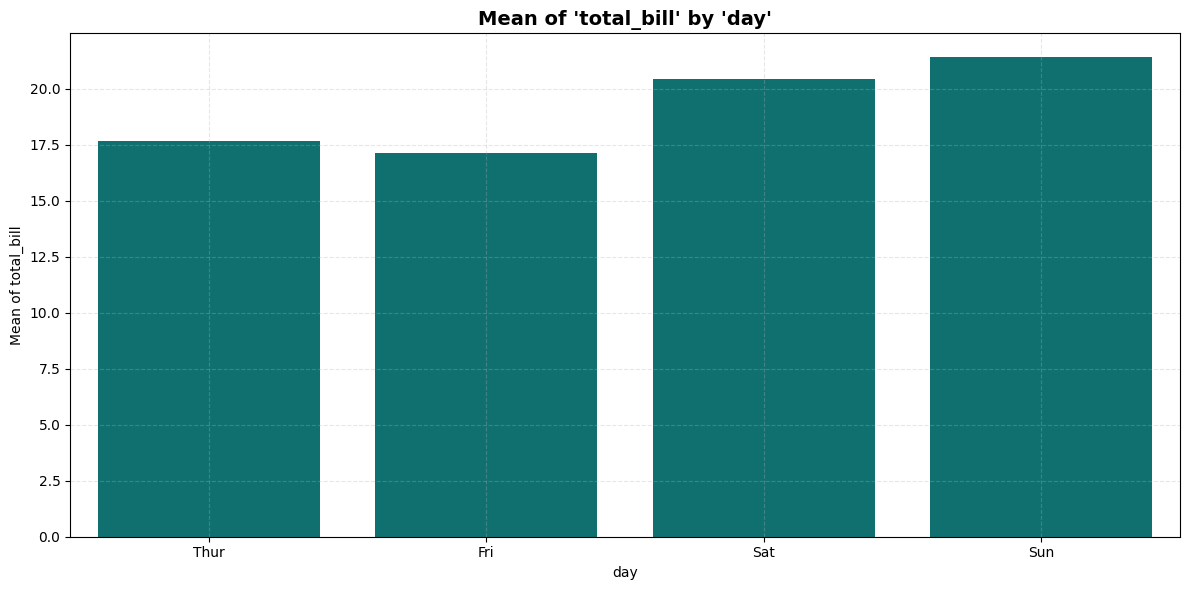

📊 Summary statistics for 'total_bill' by 'day':

      Count   Mean  Median  StdDev
day                               
Thur     62  17.68   16.20    7.89
Fri      19  17.15   15.38    8.30
Sat      87  20.44   18.24    9.48
Sun      76  21.41   19.63    8.83


In [197]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_barplot_bivariate(df, cat_feature='day', num_feature='total_bill')

---
---
## **└─ (CN) Swarm Plot**

- A Swarm Plot displays all individual data points of a numerical variable grouped by categories without overlapping points, showing both distribution and sample size.

**✅ When to Use:**

- When you want to visualize all observations (especially in small to medium datasets).
- When you want to compare distributions between categories while preserving individual data visibility.
- Useful as an alternative to box or violin plots when you want granular transparency.

**❌ When Not to Use:**

- For large datasets (1000+ rows) — it can become cluttered and slow.
- When you only care about summary statistics — use boxplots instead.
- Not ideal if there is heavy overlapping or many categories.

**⚠️ Tip**

- Combine with box or violin plots using sns.violinplot(..., inner=None) + sns.swarmplot(...) for better context.
- Consider reducing point size (size=) or using alpha for transparency.
- Use horizontal orientation (x=feature, y=category) if category labels are long.

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def plot_swarmplot(df, cat_feature, num_feature, color='orchid', size=5, title=None):
    """
    Plot a swarm plot for a numerical feature grouped by a categorical feature,
    and display group-wise summary statistics.

    Parameters:
        df (pd.DataFrame): Input dataset.
        cat_feature (str): Categorical column name (grouping).
        num_feature (str): Numerical column name (values).
        color (str): Dot color (default: 'orchid').
        size (int): Dot size (default: 5).
        title (str): Optional plot title.

    Returns:
        None. Displays the swarm plot and prints group-wise descriptive stats.
    """
    # Validation
    if cat_feature not in df.columns:
        print(f"❌ Column '{cat_feature}' not found.")
        return
    if num_feature not in df.columns:
        print(f"❌ Column '{num_feature}' not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[num_feature]):
        print(f"❌ '{num_feature}' is not numeric.")
        return

    # Drop missing
    data = df[[cat_feature, num_feature]].dropna()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.swarmplot(data=data, x=cat_feature, y=num_feature, color=color, size=size)
    plt.title(title or f"Swarm plot of '{num_feature}' by '{cat_feature}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel(num_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary statistics per category
    print(f"📊 Group-wise summary for '{num_feature}' by '{cat_feature}':\n")
    grouped = data.groupby(cat_feature, observed=False)[num_feature]
    summary = grouped.agg(['count', 'mean', 'median', 'std']).round(2)
    summary['skew'] = grouped.apply(skew).round(2)
    summary['kurtosis'] = grouped.apply(lambda x: kurtosis(x, fisher=True)).round(2)
    summary.rename(columns={
        'count': 'Count', 'mean': 'Mean', 'median': 'Median',
        'std': 'StdDev', 'skew': 'Skewness', 'kurtosis': 'Kurtosis'
    }, inplace=True)
    print(summary)

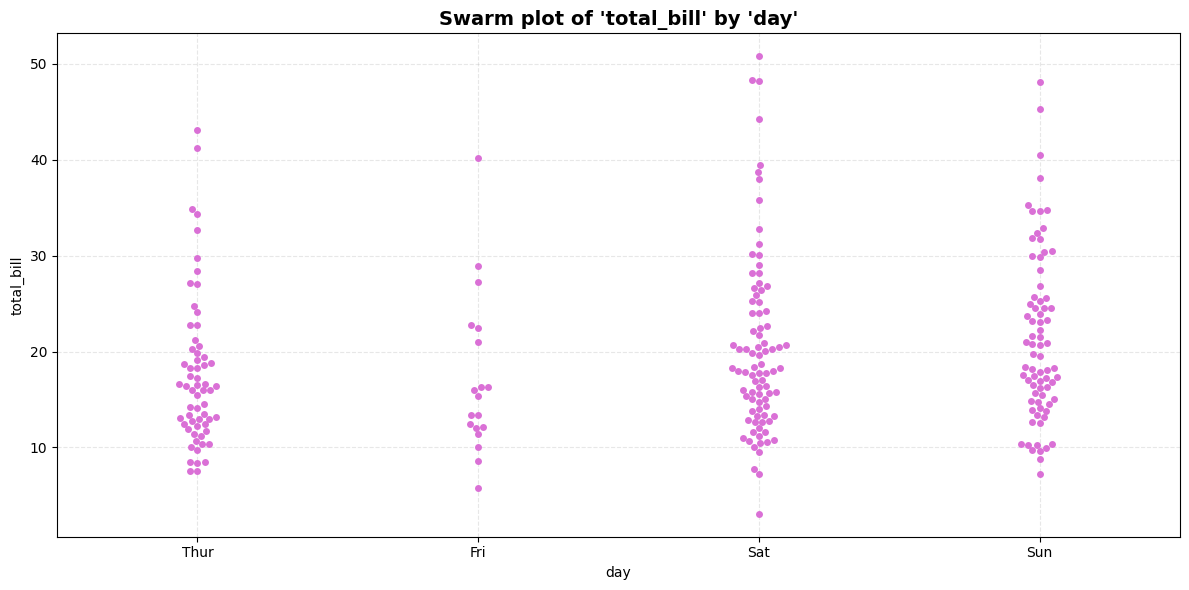

📊 Group-wise summary for 'total_bill' by 'day':

      Count   Mean  Median  StdDev  Skewness  Kurtosis
day                                                   
Thur     62  17.68   16.20    7.89      1.33      1.58
Fri      19  17.15   15.38    8.30      1.21      1.21
Sat      87  20.44   18.24    9.48      1.24      1.55
Sun      76  21.41   19.63    8.83      0.81      0.32


In [203]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_swarmplot(df=df, cat_feature='day', num_feature='total_bill')

---
---
## **└─ (CC) Clustered Bar Chart**

- A Clustered Bar Chart shows comparisons of sub-categories within each main category by placing bars side by side (grouped) for easy comparison across groups.

**✅ When to Use:**

- When comparing multiple numerical values across multiple categorical groups.
- Great for time series by category (e.g., monthly sales by region).
- To spot inter-group differences and trends within categories.

**❌ When Not to Use:**

- When the number of sub-categories is too high — it becomes cluttered.
- When exact values aren't needed — consider line plots or heatmaps for trends.
- If space is limited — grouped bars can be hard to read on small plots.

**⚠️ Tip**

- Always label bars or provide a clear legend.
- Use contrasting colors for sub-categories.
- Sort categories or use horizontal bars for better readability.
- Avoid using too many groups — stick to ≤5 sub-categories per group for clarity.

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_clustered_bar_chart(df, cat_feature, hue_feature, title=None, palette='Set2'):
    """
    Plot a clustered (grouped) bar chart for two categorical features.

    Parameters:
        df (pd.DataFrame): Input dataset.
        cat_feature (str): Primary categorical variable on x-axis.
        hue_feature (str): Secondary categorical variable for grouping (hue).
        title (str): Optional chart title.
        palette (str/list): Color palette (default: 'Set2').

    Returns:
        None. Displays the clustered bar chart.
    """
    # Validation
    if cat_feature not in df.columns or hue_feature not in df.columns:
        print(f"❌ One or both features not found in the DataFrame.")
        return
    if not (df[cat_feature].dtype == 'object' or isinstance(df[cat_feature].dtype, pd.CategoricalDtype)):
        print(f"❌ '{cat_feature}' should be a categorical feature.")
        return
    if not (df[hue_feature].dtype == 'object' or isinstance(df[hue_feature].dtype, pd.CategoricalDtype)):
        print(f"❌ '{hue_feature}' should be a categorical feature.")
        return

    # Plot
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=cat_feature, hue=hue_feature, palette=palette, edgecolor='black')

    plt.title(title or f"Clustered Bar Chart: {cat_feature} by {hue_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel("Count")
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend(title=hue_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

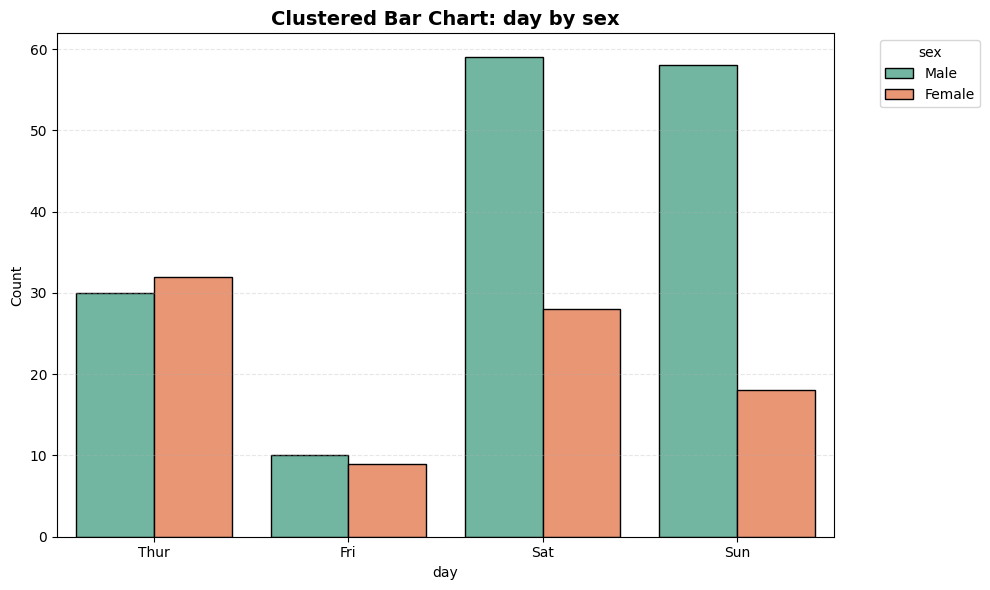

In [207]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_clustered_bar_chart(df, cat_feature='day', hue_feature='sex')

---
---
## **└─ (CC) Stacked Bar Chart**

- A Stacked Bar Chart displays part-to-whole relationships by stacking sub-categories on top of each other within the same bar for each main category.
- The height of the full bar represents the total value, while each segment represents a portion of the total.

**✅ When to Use:**

- When you want to compare total values across categories and also see the breakdown of sub-categories.
- Ideal for visualizing contributions to a total across categories (e.g., sales by product type per region).
- Useful when the order of segments is consistent and meaningful.

**❌ When Not to Use:**

- When comparing the individual segment sizes across categories — side-by-side (clustered) bars are better for that.
- If you have too many segments — makes interpretation difficult.
- When precision in comparing sub-category values is needed.

**⚠️ Tip**

- Use distinct colors for each segment and include a clear legend.
- Consider percentage-based stacking (100% stacked bar chart) when focusing on relative proportions.
- Sort categories logically to improve readability.
- Avoid 3D effects — they distort proportions and make it harder to read.

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_bar_chart(df, cat_feature, stack_feature, title=None, normalize=True, color_palette='Set2'):
    """
    Plot a stacked bar chart for two categorical features.

    Parameters:
        df (pd.DataFrame): The input dataset.
        cat_feature (str): Primary categorical variable on x-axis.
        stack_feature (str): Categorical variable to stack on top of each other.
        title (str): Custom title for the plot.
        normalize (bool): If True, show proportions instead of raw counts.
        color_palette (str or list): Matplotlib-compatible color palette.

    Returns:
        None. Displays the stacked bar chart.
    """
    # Check existence
    if cat_feature not in df.columns or stack_feature not in df.columns:
        print("❌ One or both features not found in the DataFrame.")
        return

    # Create a crosstab
    ctab = pd.crosstab(df[cat_feature], df[stack_feature])

    # Normalize if needed
    if normalize:
        ctab = ctab.div(ctab.sum(axis=1), axis=0)

    # Plot
    ctab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap=color_palette, edgecolor='black')

    plt.title(title or f"Stacked Bar Chart of {cat_feature} by {stack_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(cat_feature)
    plt.ylabel("Proportion" if normalize else "Count")
    plt.legend(title=stack_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

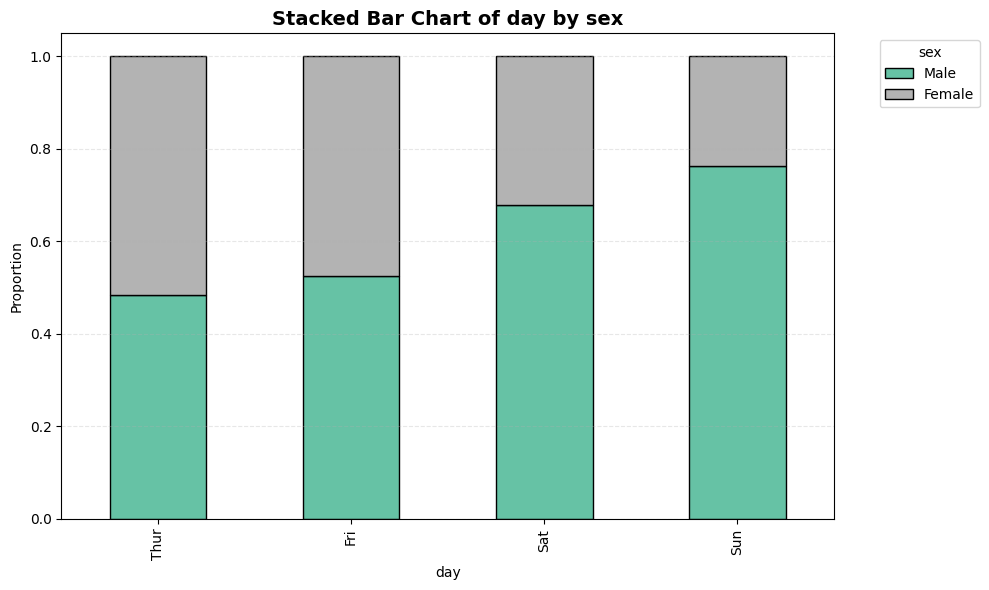

In [211]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_stacked_bar_chart(df, cat_feature='day', stack_feature='sex')

---
---
## **└─ (CC) Mosaic Chart**

- A Mosaic Chart is a space-filling plot used to visualize the relationship between two or more categorical variables. Each rectangle’s area is proportional to the frequency or proportion of the corresponding category combination.
- It’s like a 2D extension of a stacked bar chart, ideal for showing joint distributions.

**✅ When to Use:**

- To explore interactions between two or more categorical variables.
- When you want to visualize contingency tables or chi-square test inputs.
- Useful for identifying imbalances, patterns, or associations in categorical data.

**❌ When Not to Use:**

- When one or both variables have too many categories — becomes cluttered.
- When comparing numerical data — use bar, box, or violin plots instead.
- If you need exact values — labels can be hard to read.

**⚠️ Tip**

- Use color to highlight specific categories or proportions.
- Add percentage labels to improve interpretability.
- Combine with a chi-square test to detect statistically significant relationships.
- Keep variable order logical for better pattern recognition.

In [218]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

def plot_mosaic_chart(df, feature_x, feature_y, title=None, gap=0.01, color_func=None):
    """
    Plot a mosaic chart for two categorical features.

    Parameters:
        df (pd.DataFrame): Input dataset.
        feature_x (str): First categorical feature (shown on x-axis).
        feature_y (str): Second categorical feature (shown as subdivisions within x).
        title (str): Optional plot title.
        gap (float): Gap between tiles (default: 0.01).
        color_func (function): Optional function for custom tile coloring.

    Returns:
        None. Displays the mosaic plot.
    """
    if feature_x not in df.columns or feature_y not in df.columns:
        print("❌ One or both features not found.")
        return
    
    data = df[[feature_x, feature_y]].dropna()
    grouped = data.groupby([feature_x, feature_y], observed=False).size()
    grouped_dict = grouped.to_dict()

    plt.figure(figsize=(10, 6))
    if color_func:
        mosaic(grouped_dict, gap=gap, properties=color_func)
    else:
        mosaic(grouped_dict, gap=gap)
    
    plt.title(title or f"Mosaic Plot: '{feature_x}' vs '{feature_y}'", fontsize=14, fontweight='bold')
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

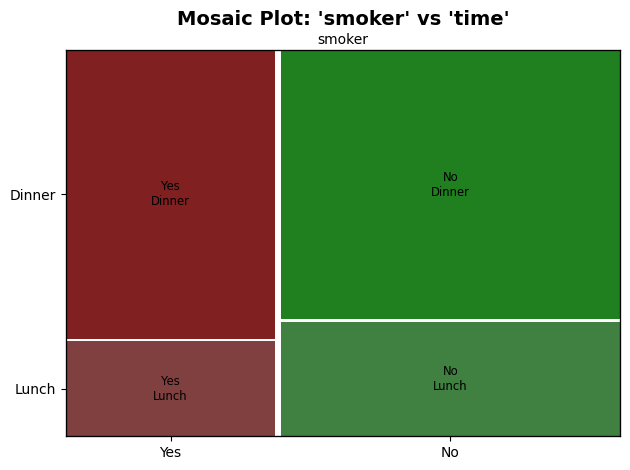

In [219]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_mosaic_chart(df, feature_x='smoker', feature_y='time')

---
---
## **└─ (CC) Heatmap**

- A categorical heatmap visualizes the frequency (or proportion) of combinations between two categorical variables using color intensity in a 2D grid.
- Each cell's color represents the count or percentage of records for a specific pair of categories.

**✅ When to Use:**

- When you want to visualize relationships between two categorical features.
- Great for spotting strong associations, imbalances, or missing combinations.
- Useful when there are multiple levels in each category but not too many.

**❌ When Not to Use:**

- If either variable has too many unique values, the chart can become unreadable.
- When showing exact counts is important — a cross-tab table might be better.
- Not suitable for visualizing numerical values directly.

**⚠️ Tip**

- Use annot=True to display the count or % values in each cell.
- Normalize to row or column percentages if comparing proportions.
- Choose a sequential colormap (e.g., Blues, YlGnBu) to emphasize intensity.
- Rotate axis labels and adjust figure size for readability if there are many categories.

In [224]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cat_heatmap(
    df,
    cat1,
    cat2,
    title=None,
    cmap="Blues",
    show="count",  # Options: "count", "percent_row", "percent_total", "both"
    fmt=".1f",
    annot=True
):
    """
    Plot a heatmap for two categorical features, with counts and/or percentage annotations.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        cat1 (str): Categorical feature for rows.
        cat2 (str): Categorical feature for columns.
        title (str): Optional custom title.
        cmap (str): Color palette.
        show (str): One of "count", "percent_row", "percent_total", "both".
        fmt (str): Format string for percentages (e.g., '.1f').
        annot (bool): Whether to annotate heatmap cells.

    Returns:
        None. Displays the heatmap.
    """
    # Validation
    if cat1 not in df.columns or cat2 not in df.columns:
        print("❌ One or both features not found in the DataFrame.")
        return

    # Count matrix
    count_table = pd.crosstab(df[cat1], df[cat2])

    if show == "count":
        plot_data = count_table
        annot_data = count_table if annot else None
        fmt_used = "d"

    elif show == "percent_row":
        percent_table = count_table.div(count_table.sum(axis=1), axis=0) * 100
        plot_data = percent_table
        annot_data = percent_table.round(1).astype(str) + "%" if annot else None
        fmt_used = ""  # not used since we pass formatted strings

    elif show == "percent_total":
        percent_table = count_table / count_table.sum().sum() * 100
        plot_data = percent_table
        annot_data = percent_table.round(1).astype(str) + "%" if annot else None
        fmt_used = ""

    elif show == "both":
        percent_table = count_table.div(count_table.sum(axis=1), axis=0) * 100
        annot_data = count_table.astype(str) + "\n(" + percent_table.round(1).astype(str) + "%)" if annot else None
        plot_data = percent_table
        fmt_used = ""

    else:
        print("❌ Invalid `show` value. Use 'count', 'percent_row', 'percent_total', or 'both'.")
        return

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(plot_data, annot=annot_data, fmt=fmt_used, cmap=cmap,
                cbar=(show != "both"), linewidths=0.5, linecolor='gray')

    plt.title(title or f"Heatmap of '{cat1}' vs '{cat2}'", fontsize=14, fontweight='bold')
    plt.xlabel(cat2)
    plt.ylabel(cat1)
    plt.tight_layout()
    plt.show()

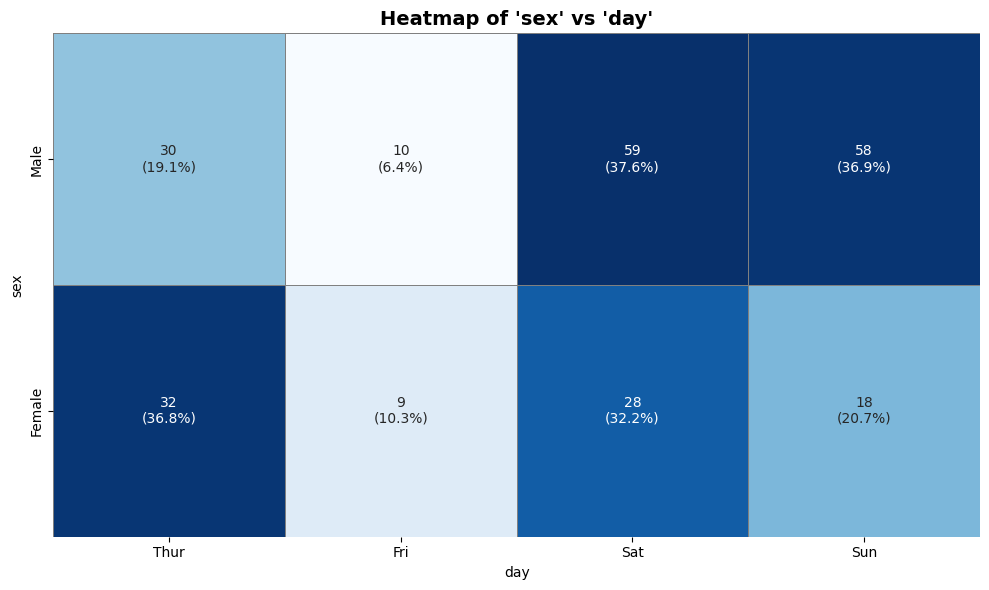

In [226]:
import seaborn as sns
df = sns.load_dataset("tips")

# Show count heatmap
# plot_cat_heatmap(df, 'sex', 'day', show='count')

# Show row-wise percentage heatmap
# plot_cat_heatmap(df, 'sex', 'day', show='percent_row')

# Show total percentage
# plot_cat_heatmap(df, 'sex', 'day', show='percent_total')

# Show both count and row-percentage
plot_cat_heatmap(df, 'sex', 'day', show='both')

---
---
## **└─ (CC) Treemap**

- A categorical treemap visualizes the joint distribution of two categorical variables by displaying nested rectangles.
- The area of each rectangle is proportional to the frequency or percentage of each category combination, often grouped hierarchically.

**✅ When to Use:**

- When you want to explore part-to-whole relationships across two categorical features.
- Helpful for showing dominant combinations or imbalances in category pairs.
- Great for summarizing a large frequency table in a compact, visual format.

**❌ When Not to Use:**

- When precise comparisons are needed — consider a heatmap or clustered bar chart instead.
- If one or both variables have too many unique categories — can become cluttered.
- Not suitable for time-series or continuous numeric data.

**⚠️ Tip**

- Use color to highlight a secondary variable or percentage.
- Include labels and percentages on the treemap to aid interpretation.
- Consider filtering to the top N categories for clarity.
- Use a hierarchical order: primary category → subcategory.

In [237]:
import matplotlib.pyplot as plt
import squarify
import pandas as pd

def plot_treemap_2cat(df, cat1, cat2, title=None, cmap='Spectral'):
    """
    Plot a treemap for two categorical features combined, showing counts per combination.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        cat1 (str): First categorical column.
        cat2 (str): Second categorical column.
        title (str): Optional plot title.
        cmap (str): Matplotlib colormap for coloring blocks.

    Returns:
        None. Displays the treemap.
    """
    # Validate columns
    if cat1 not in df.columns or cat2 not in df.columns:
        print(f"❌ One or both columns '{cat1}', '{cat2}' not found.")
        return

    # Group by both categories and count
    grouped = df.groupby([cat1, cat2], observed=False).size().reset_index(name='count')

    # Filter out zero or negative counts
    grouped = grouped[grouped['count'] > 0]
    if grouped.empty:
        print("❌ No data to plot after filtering zero counts.")
        return

    # Prepare labels and sizes
    labels = grouped.apply(lambda row: f"{row[cat1]}\n{row[cat2]}\n{row['count']}", axis=1).tolist()
    sizes = grouped['count'].values

    total = sizes.sum()
    if total == 0:
        print("❌ Sum of counts is zero, cannot plot treemap.")
        return

    # Normalize sizes to percentages
    sizes = sizes / total * 100

    # Colors from colormap
    cmap = plt.get_cmap(cmap)
    colors = [cmap(i / len(sizes)) for i in range(len(sizes))]

    plt.figure(figsize=(14, 8))
    squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8, edgecolor='white', linewidth=2)
    plt.axis('off')
    plt.title(title or f"Treemap of '{cat1}' and '{cat2}'", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

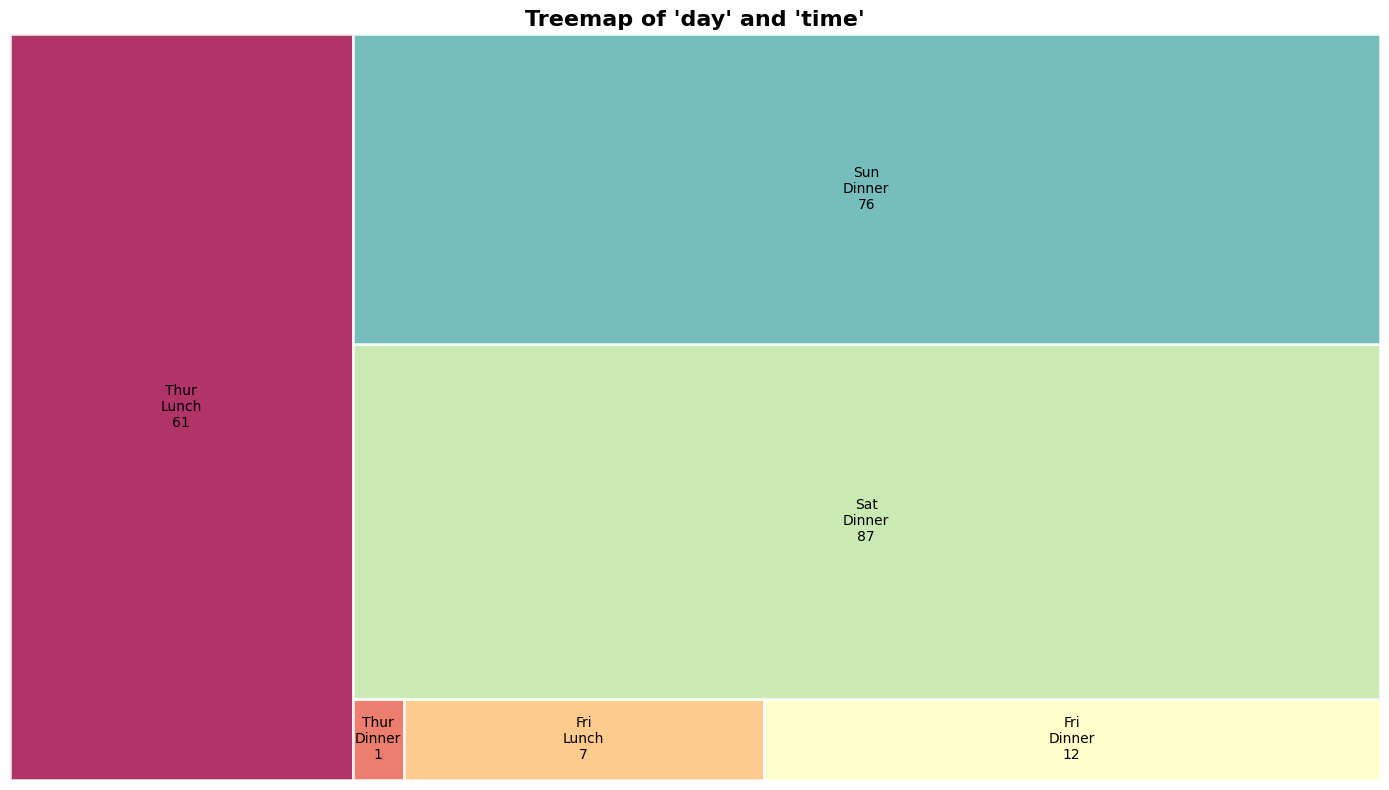

In [238]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_treemap_2cat(df, 'day', 'time')

---
---
---
# **🟣 Multivariate Plots**

| Plot Types                                 |
| ------------------------------------------ |
| Pairplot (Seaborn), Bubble Plot            |
| FacetGrid, Trellis Plot                    |
| Colored Scatter Plot / Size or Hue-encoded |
| 3D Scatter Plot (Plotly, Matplotlib 3D)    |


---
---
## **└─ (N\*) Correlation Heatmap**

- A Correlation Heatmap is a graphical representation of a correlation matrix, where colors encode the strength and direction of relationships between numerical variables.
- It provides a quick visual overview of how variables are related, highlighting strong positive, negative, or no correlations.

**✅ When to Use:**

- To explore and summarize relationships among multiple continuous variables.
- To identify highly correlated variables for feature selection or multicollinearity checks.
- When preparing data for modeling to understand variable interactions.

**❌ When Not to Use:**

- For categorical variables without numeric encoding.
- When the dataset is too large and the heatmap becomes cluttered and hard to interpret.
- When detailed causal analysis is required—correlation does not imply causation.

**⚠️ Tip**

- Use diverging color palettes (e.g., coolwarm, RdBu) to distinguish positive and negative correlations clearly.
- Annotate cells with correlation coefficients for precise interpretation.
- Apply hierarchical clustering or reorder variables to reveal patterns or clusters.
- Always complement with scatterplots or other analyses to confirm relationships.

In [277]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_correlation_heatmap(df, features=None, annot=True, cmap='coolwarm', title=None):
    """
    Plot a correlation heatmap for numerical features.

    Parameters:
        df (pd.DataFrame): Input dataset.
        features (list or None): List of numerical columns to include. If None, all numeric columns are used.
        annot (bool): Whether to annotate cells with correlation coefficients (default: True).
        cmap (str): Colormap for heatmap (default: 'coolwarm').
        title (str or None): Optional plot title.

    Returns:
        None. Displays the correlation heatmap.
    """
    # Select numerical features
    if features is None:
        features = df.select_dtypes(include='number').columns.tolist()
    else:
        missing = [f for f in features if f not in df.columns]
        if missing:
            print(f"❌ Columns not found: {missing}")
            return

    # Calculate correlation matrix
    corr_matrix = df[features].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=annot, fmt=".2f", cmap=cmap, center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})

    plt.title(title or "Correlation Heatmap", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

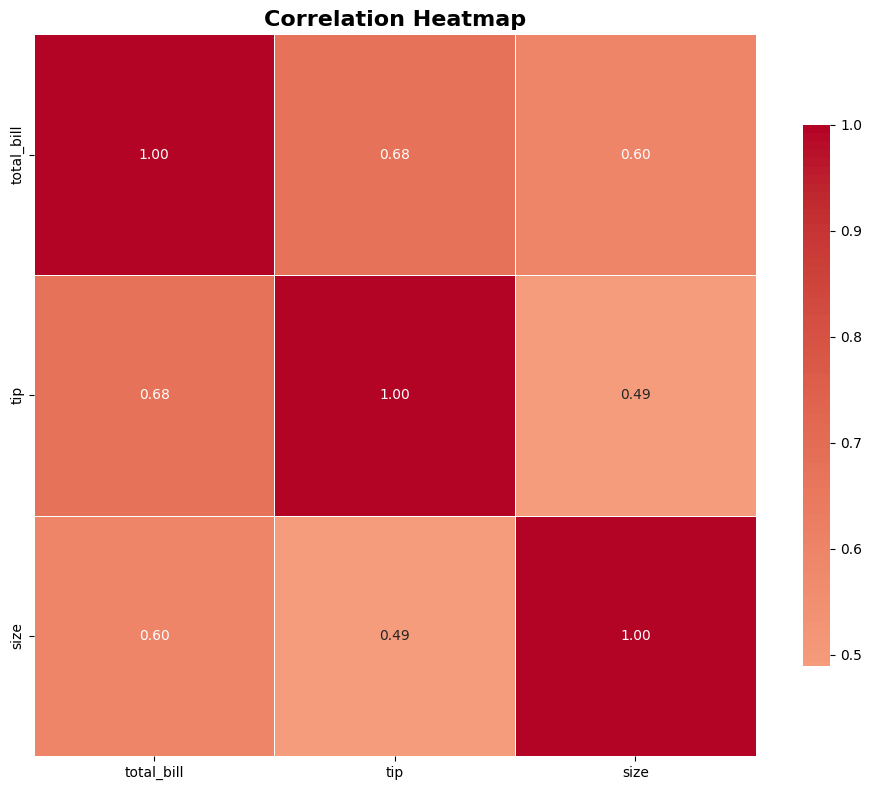

In [279]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_correlation_heatmap(df, features=['total_bill', 'tip', 'size'])

---
---
## **└─ (CN\*) Pair Plot**

- A pair plot displays scatter plots (and optionally histograms or KDEs) of all pairwise combinations of numerical variables in a dataset.
- It helps visualize relationships, correlations, and distributions simultaneously across multiple variables.

**✅ When to Use:**

- When you want to explore relationships and patterns among multiple numerical features.
- Great for identifying correlations, clusters, or outliers.
- Useful as a quick overview before deeper analysis or modeling.

**❌ When Not to Use:**

- With a very large number of variables — the plot becomes cluttered and hard to interpret.
- When you need precise numeric summaries — use correlation matrices or statistical tests instead.
- Not suitable for datasets with mostly categorical features.

**⚠️ Tip**

- Use the hue parameter to color points by a categorical variable and reveal group patterns.
- Adjust plot size and aspect ratio for better readability.
- Limit variables to a manageable subset (e.g., top correlated features).
- For large datasets, consider sampling to reduce overplotting.

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_pairplot(df, features=None, hue=None, kind='scatter', diag_kind='hist', title=None, palette='Set2'):
    """
    Plot a pairplot (scatterplot matrix) for numerical features in the DataFrame.

    Parameters:
        df (pd.DataFrame): Input dataset.
        features (list or None): List of numerical columns to include. If None, all numeric columns are used.
        hue (str or None): Categorical column name for color grouping (optional).
        kind (str): Kind of plot for off-diagonal: 'scatter' (default), 'reg', 'kde', or 'hist'.
        diag_kind (str): Kind of plot for diagonal: 'hist' (default) or 'kde'.
        title (str or None): Optional title for the plot.
        palette (str or list): Color palette for the hue groups.

    Returns:
        None. Displays the pairplot.
    """

    # Select features
    if features is None:
        features = df.select_dtypes(include='number').columns.tolist()
    else:
        missing = [f for f in features if f not in df.columns]
        if missing:
            print(f"❌ Columns not found: {missing}")
            return

    # Check hue column
    if hue and hue not in df.columns:
        print(f"❌ Hue column '{hue}' not found.")
        return

    # Create pairplot
    pairplot = sns.pairplot(df, vars=features, hue=hue, kind=kind, diag_kind=diag_kind, palette=palette)

    if title:
        plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    plt.show()

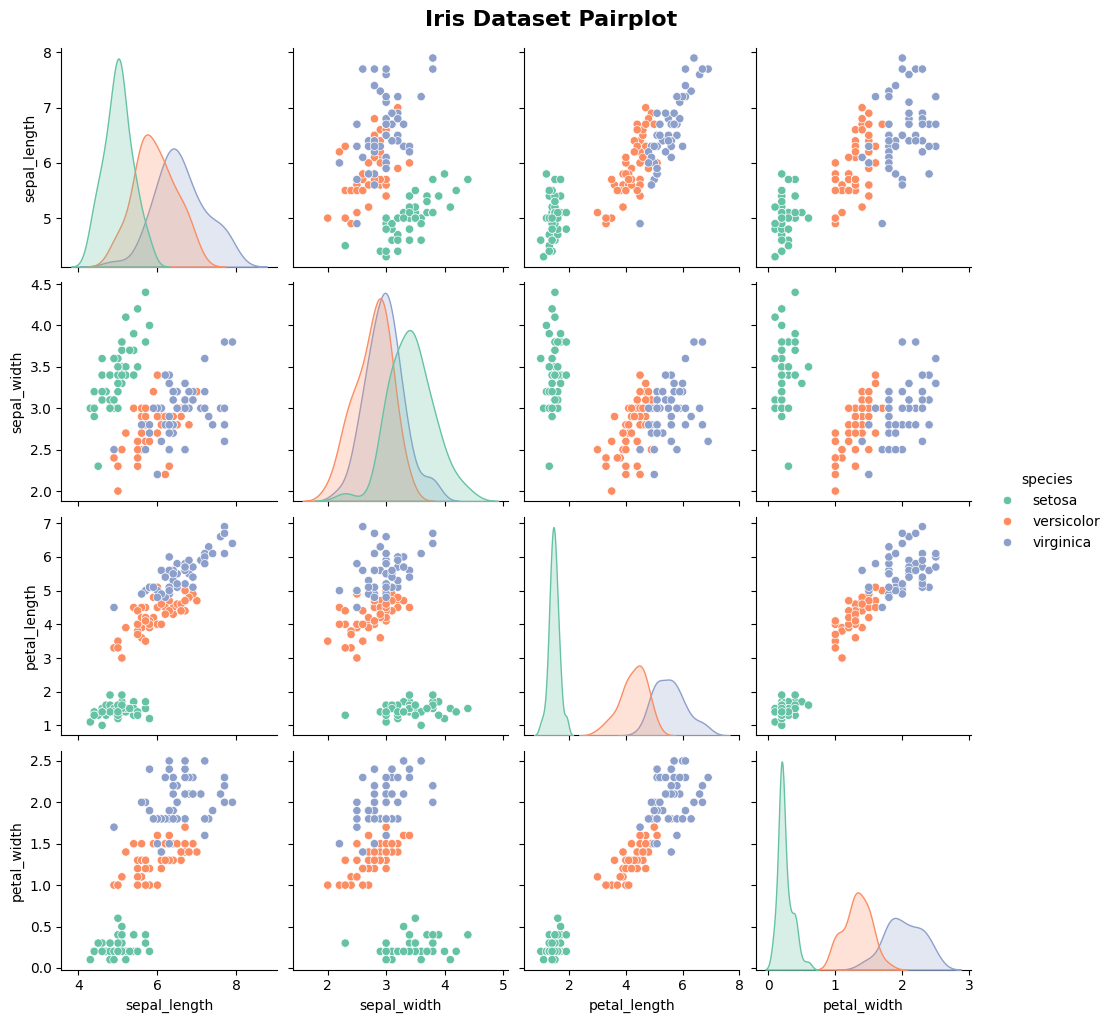

In [244]:
import seaborn as sns
df = sns.load_dataset("iris")

plot_pairplot(
    df,
    features=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    hue='species', 
    kind='scatter',
    diag_kind='kde',
    title="Iris Dataset Pairplot"
)

---
---
## **└─ (CNN) Coloured Scatter Plot**

- A colored scatter plot visualizes the relationship between two numerical variables, using color to encode a third variable (categorical or continuous).
- It enhances the basic scatter plot by adding an extra dimension of information through color.

**✅ When to Use:**

- When you want to explore bivariate relationships and simultaneously highlight groupings or trends based on a third variable.
- Useful to detect clusters, patterns, or interactions that involve three variables.
- Works well for both categorical and continuous color encodings.

**❌ When Not to Use:**

- When you have too many distinct categories (colors) — the plot becomes hard to interpret.
- If the color variable has no meaningful relation to the plotted features, it can confuse rather than clarify.
- Not ideal for very large datasets without additional techniques to reduce overplotting.

**⚠️ Tip**

- Choose color palettes that provide good contrast and are colorblind-friendly.
- Use legends to clearly indicate what colors represent.
- Combine with point size or shape variations to encode additional variables if needed.
- Consider transparency (alpha) to handle overplotting in dense regions.

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_colored_scatter(df, x_feature, y_feature, color_feature=None, 
                         palette='viridis', size=(10,6), title=None):
    """
    Plot a scatter plot with optional color encoding by a third feature.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Column name for x-axis.
        y_feature (str): Column name for y-axis.
        color_feature (str or None): Optional column name for color encoding.
        palette (str or list): Color palette (default 'viridis').
        size (tuple): Figure size (width, height).
        title (str): Optional plot title.

    Returns:
        None. Displays the scatter plot.
    """

    if x_feature not in df.columns or y_feature not in df.columns:
        print(f"❌ '{x_feature}' or '{y_feature}' not found in DataFrame.")
        return
    if color_feature and color_feature not in df.columns:
        print(f"❌ Color feature '{color_feature}' not found in DataFrame.")
        return

    plt.figure(figsize=size)
    if color_feature:
        sns.scatterplot(data=df, x=x_feature, y=y_feature, hue=color_feature, palette=palette, s=60, alpha=0.8)
        plt.legend(title=color_feature)
    else:
        sns.scatterplot(data=df, x=x_feature, y=y_feature, color='steelblue', s=60, alpha=0.8)

    plt.title(title or f"Scatter Plot: {y_feature} vs {x_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

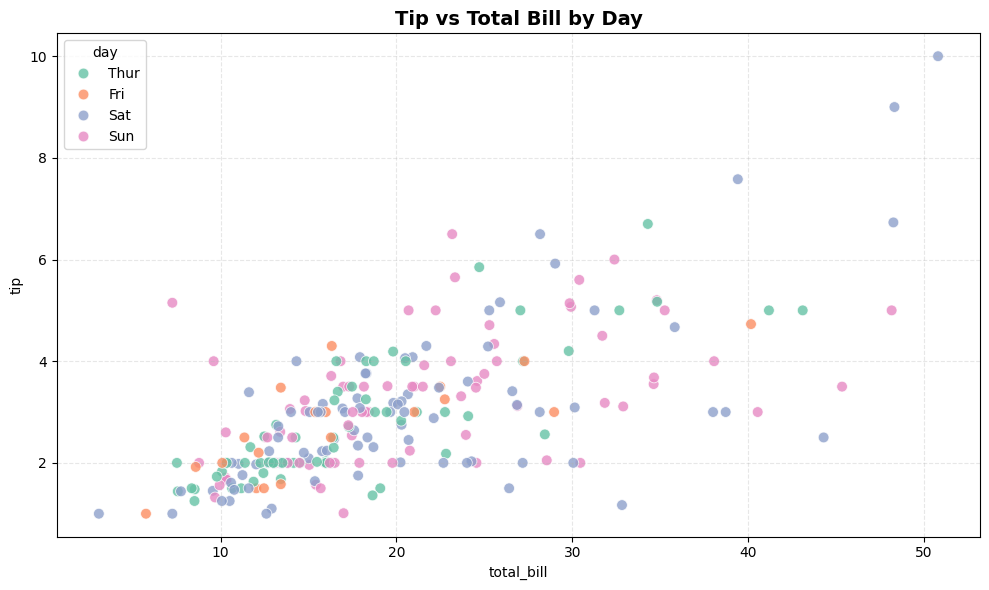

In [257]:
import seaborn as sns
df = sns.load_dataset('tips')

# Scatter with color by categorical feature
plot_colored_scatter(df, 'total_bill', 'tip', color_feature='day', palette='Set2', title="Tip vs Total Bill by Day")

---
---
## **└─ (CNN) Trellis Plot**

- A Trellis plot (also called lattice plot or small multiples) displays multiple small plots arranged in a grid, each showing the relationship between variables conditioned on one or more categorical variables.
- It helps visualize how patterns vary across subsets of the data.

**✅ When to Use:**

- To compare distributions or relationships across different groups or categories.
- When you want to break down complex data into simpler, comparable views.
- Ideal for detecting interactions and variations across levels of a categorical variable.

**❌ When Not to Use:**

- If you have too many categories, resulting in too many small plots that are hard to interpret.
- When individual plots are too sparse or too noisy.
- If the audience is unfamiliar with small multiple concepts—it might be overwhelming without proper explanation.

**⚠️ Tip**

- Keep individual plots simple and consistent in style for easy comparison.
- Use clear, descriptive titles or labels for each subplot.
- Adjust the layout (rows and columns) to maximize readability.
- Limit the number of conditioning variables to avoid clutter.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_trellis(df, x_feature, y_feature, facet_feature, kind='scatter', 
                 palette='Set1', height=4, aspect=1, title=None):
    """
    Create a Trellis (small multiples) plot faceted by a categorical variable.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Feature for x-axis.
        y_feature (str): Feature for y-axis.
        facet_feature (str): Categorical feature to create facets (small multiples).
        kind (str): Type of plot: 'scatter', 'line', 'box', 'violin', 'bar' (default 'scatter').
        palette (str or list): Color palette.
        height (float): Height of each facet.
        aspect (float): Aspect ratio of each facet.
        title (str): Overall plot title.

    Returns:
        None. Displays the plot.
    """

    if facet_feature not in df.columns:
        print(f"❌ Column '{facet_feature}' not found in DataFrame.")
        return

    if x_feature not in df.columns or y_feature not in df.columns:
        print(f"❌ Check x_feature or y_feature columns.")
        return

    g = sns.FacetGrid(df, col=facet_feature, col_wrap=4, height=height, aspect=aspect)

    plot_map = {
        'scatter': sns.scatterplot,
        'line': sns.lineplot,
        'box': sns.boxplot,
        'violin': sns.violinplot,
        'bar': sns.barplot
    }

    if kind not in plot_map:
        print(f"❌ Plot kind '{kind}' not supported.")
        return

    # Because boxplot and violinplot expect categorical axis, we swap axes if needed
    if kind in ['box', 'violin']:
        g.map_dataframe(plot_map[kind], x=facet_feature, y=y_feature)
    else:
        g.map_dataframe(plot_map[kind], x=x_feature, y=y_feature)

    if title:
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle(title, fontsize=16, fontweight='bold')

    plt.show()

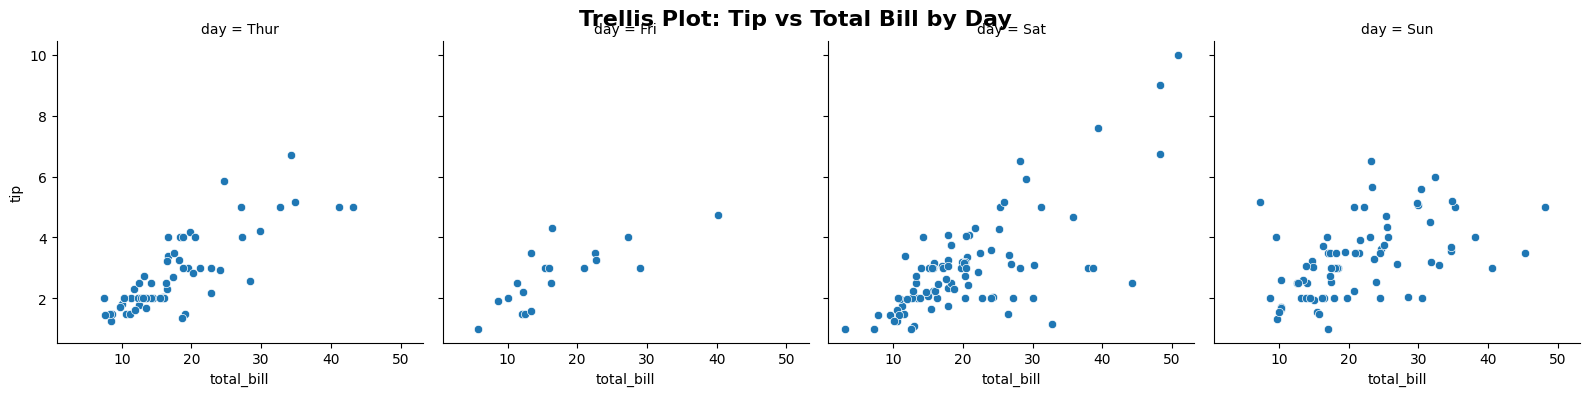

In [254]:
import seaborn as sns
df = sns.load_dataset('tips')

plot_trellis(
    df, 
    x_feature='total_bill', 
    y_feature='tip', 
    facet_feature='day', 
    kind='scatter', 
    palette='Set1',
    height=4,
    aspect=1,
    title='Trellis Plot: Tip vs Total Bill by Day'
)

---
---
## **└─ (CCN) Boxplot**

- This plot visualizes the distribution of a numerical variable across combinations of two categorical variables, using a grouped boxplot layout.
- Each box represents the spread (IQR, median, outliers) of the numerical values for a specific subgroup, defined by one x-axis category and one hue (color) category.
- The accompanying ANOVA test helps statistically assess whether differences in group means are significant.

**✅ When to Use:**

- To compare distributions of a continuous variable across two categorical factors simultaneously.
- To explore interaction patterns (e.g., does the effect of X on Y change across different levels of HUE?).
- When your goal is both visual understanding and statistical validation (e.g., via ANOVA).

**❌ When Not to Use:**

- If one of the categorical features has too many unique values, making the chart cluttered or unreadable.
- If the data is highly unbalanced across groups (very few records in some combinations).
- If the numeric variable has extreme outliers, consider transformation first.

**⚠️ Tip**

- Consider using violinplot() or pointplot() if you want to visualize density or means with confidence intervals.
- If p-value < 0.05, differences between groups are statistically significant. Otherwise, they may be due to chance.
- Always check assumptions of ANOVA: normality, homogeneity of variance, and independent observations.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import f_oneway
from IPython.display import display

def plot_multivariate_boxplot(df, x_feature, hue_feature, y_feature, figsize=(12, 6), palette='Set2'):
    """
    Plot a boxplot to visualize the distribution of a numerical variable across two categorical variables.
    Also prints descriptive statistics and ANOVA test results.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): First categorical variable (x-axis).
        hue_feature (str): Second categorical variable (color/hue grouping).
        y_feature (str): Numerical variable (y-axis).
        figsize (tuple): Figure size (default: (12, 6)).
        palette (str or list): Color palette for hue categories.

    Returns:
        None. Displays the boxplot and prints stats + ANOVA.
    """

    # ✅ Validate input columns
    for col in [x_feature, hue_feature, y_feature]:
        if col not in df.columns:
            print(f"❌ Column '{col}' not found.")
            return

    if not pd.api.types.is_numeric_dtype(df[y_feature]):
        print(f"❌ Column '{y_feature}' must be numeric.")
        return
    if df[x_feature].dtype.name not in ['category', 'object']:
        df[x_feature] = df[x_feature].astype("category")
    if df[hue_feature].dtype.name not in ['category', 'object']:
        df[hue_feature] = df[hue_feature].astype("category")

    # ✅ Plotting
    plt.figure(figsize=figsize)
    sns.boxplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue=hue_feature,
        palette=palette
    )

    plt.title(f"Boxplot of {y_feature} by {x_feature} and {hue_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend(title=hue_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    # ✅ Descriptive Statistics
    print("└── 📊 Descriptive Statistics:")
    desc_stats = df.groupby([x_feature, hue_feature], observed=False)[y_feature].describe()
    display(desc_stats)

    # ✅ ANOVA Test
    print("└── 🧪 ANOVA Test Results:")
    grouped_data = [group[y_feature].dropna().values for _, group in df.groupby([x_feature, hue_feature], observed=False)]
    anova = f_oneway(*grouped_data)

    print(f"    └── F-statistic: {anova.statistic:.4f}")
    print(f"    └── p-value: {anova.pvalue:.4f}")
    if anova.pvalue < 0.05:
        print("    └── ✅ Statistically significant differences detected (p < 0.05).")
    else:
        print("    └── ⚠️ No statistically significant differences (p ≥ 0.05).")

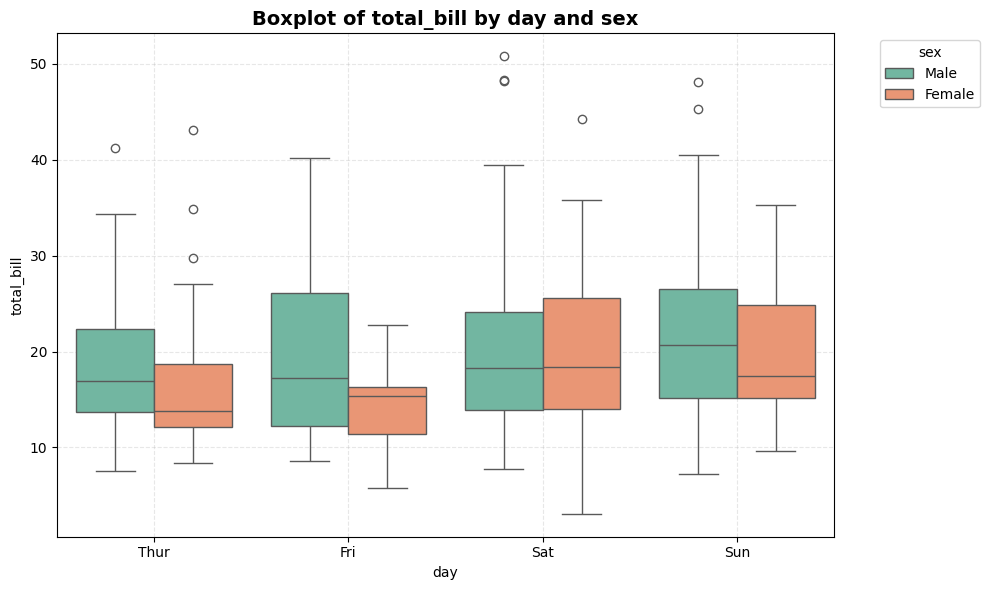

└── 📊 Descriptive Statistics:


count       mean        std   min      25%     50%      75%  \
day  sex                                                                   
Thur Male     30.0  18.714667   8.019728  7.51  13.6975  16.975  22.3600   
     Female   32.0  16.715312   7.759764  8.35  12.1625  13.785  18.6750   
Fri  Male     10.0  19.857000  10.015847  8.58  12.2350  17.215  26.0825   
     Female    9.0  14.145556   4.788547  5.75  11.3500  15.380  16.2700   
Sat  Male     59.0  20.802542   9.836306  7.74  13.9050  18.240  24.1650   
     Female   28.0  19.680357   8.806470  3.07  14.0500  18.360  25.5625   
Sun  Male     58.0  21.887241   9.129142  7.25  15.1350  20.725  26.5500   
     Female   18.0  19.872222   7.837513  9.60  15.1750  17.410  24.8975   

               max  
day  sex            
Thur Male    41.19  
     Female  43.11  
Fri  Male    40.17  
     Female  22.75  
Sat  Male    50.81  
     Female  44.30  
Sun  Male    48.17  
     Female  35.26

└── 🧪 ANOVA Test Results:
    └── F-statistic: 1.7301
    └── p-value: 0.1027
    └── ⚠️ No statistically significant differences (p ≥ 0.05).


In [15]:
import seaborn as sns
df = sns.load_dataset("tips")

plot_multivariate_boxplot(
    df,
    x_feature='day',
    hue_feature='sex',
    y_feature='total_bill',
    figsize=(10, 6)
)

---
---
## **└─ (CNNN) Bubble Plot**

- A Bubble Plot is a scatter plot variation where each point’s size (and optionally color) represents an additional numerical variable.
- It visualizes relationships between two variables while encoding a third variable’s magnitude through bubble size.

**✅ When to Use:**

- When you want to show three dimensions of data in a two-dimensional plot.
- To highlight relative importance, frequency, or magnitude alongside the main x-y relationship.
- Useful for spotting clusters, trends, or outliers with size as an extra cue.

**❌ When Not to Use:**

- If bubble sizes vary too widely, small bubbles can be hard to see and large bubbles can overlap, causing clutter.
- Not suitable when precise comparison of values is needed—size perception can be misleading.
- Avoid if dataset is too dense, leading to overlapping bubbles and visual confusion.

**⚠️ Tip**

- Use a size scale legend to help interpret bubble sizes.
- Choose size and color palettes that provide good visual contrast and clarity.
- Consider setting a maximum bubble size to reduce overlap.
- Combine with transparency (alpha) to mitigate overplotting.

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_bubble(df, x_feature, y_feature, size_feature, hue_feature=None, 
                size_scale=200, palette='viridis', alpha=0.7, title=None):
    """
    Plot a bubble plot with x, y positions, bubble size, and optional hue color.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Column name for x-axis (numeric).
        y_feature (str): Column name for y-axis (numeric).
        size_feature (str): Column name for bubble sizes (numeric).
        hue_feature (str or None): Optional categorical column name for coloring bubbles.
        size_scale (int or float): Scaling factor for bubble sizes (default: 200).
        palette (str or list): Color palette for hue groups (default: 'viridis').
        alpha (float): Transparency of bubbles (default: 0.7).
        title (str or None): Optional plot title.

    Returns:
        None. Displays the bubble plot.
    """

    # Validate columns
    for col in [x_feature, y_feature, size_feature]:
        if col not in df.columns:
            print(f"❌ Column '{col}' not found.")
            return
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"❌ Column '{col}' must be numeric.")
            return

    if hue_feature and hue_feature not in df.columns:
        print(f"❌ Hue column '{hue_feature}' not found.")
        return

    plt.figure(figsize=(10, 6))

    if hue_feature:
        sns.scatterplot(
            data=df,
            x=x_feature,
            y=y_feature,
            size=size_feature,
            hue=hue_feature,
            sizes=(20, size_scale),
            palette=palette,
            alpha=alpha,
            edgecolor='black',
            linewidth=0.5
        )
    else:
        sns.scatterplot(
            data=df,
            x=x_feature,
            y=y_feature,
            size=size_feature,
            sizes=(20, size_scale),
            color='steelblue',
            alpha=alpha,
            edgecolor='black',
            linewidth=0.5
        )

    plt.title(title or f"Bubble Plot of {y_feature} vs {x_feature} sized by {size_feature}", fontsize=14, fontweight='bold')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend(title=hue_feature if hue_feature else size_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

int64


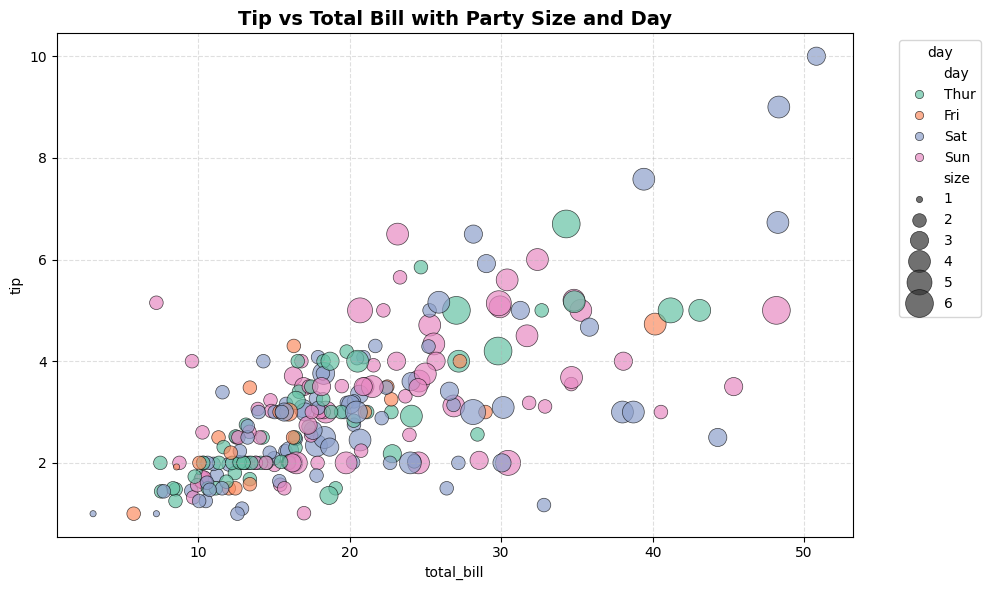

In [272]:
import seaborn as sns
df = sns.load_dataset("tips")

print(df['size'].dtype)

plot_bubble(
    df,
    x_feature='total_bill', y_feature='tip', size_feature='size', hue_feature='day',
    size_scale=400, palette='Set2', title="Tip vs Total Bill with Party Size and Day"
)

---
---
## **└─ (CNNN) 3D Scatter Plot**

- A 3D Scatter Plot visualizes the relationship between three numerical variables using three spatial axes (x, y, z).
- Each point is positioned in a 3D coordinate system, allowing insights into complex interactions beyond 2D.

**✅ When to Use:**

- When you want to explore or present relationships among three continuous variables simultaneously.
- Useful for detecting clusters, trends, or outliers in three-dimensional data.
- Helpful when spatial or multi-dimensional patterns are important.

**❌ When Not to Use:**

- For large datasets where many points overlap, causing clutter and loss of clarity.
- When 3D perspective causes visual distortion or makes interpretation difficult.
- If the third dimension doesn’t add meaningful insight, a 2D plot might be clearer.

**⚠️ Tip**

- Enable interactive rotation in your visualization tool for better perspective.
- Use color and size to encode additional variables if needed.
- Avoid overcrowding the plot — consider sampling or filtering.
- Label axes clearly and include a legend if colors or sizes are used.

In [275]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
import seaborn as sns

def plot_3d_scatter(df, x_feature, y_feature, z_feature, color_feature=None, 
                    palette='viridis', size=50, title=None):
    """
    Plot a 3D scatter plot with optional color encoding.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Column name for x-axis.
        y_feature (str): Column name for y-axis.
        z_feature (str): Column name for z-axis.
        color_feature (str or None): Optional column name for color encoding.
        palette (str or list): Color palette (default 'viridis').
        size (int): Marker size.
        title (str): Optional plot title.

    Returns:
        None. Displays the 3D scatter plot.
    """
    # Validate columns
    for feature in [x_feature, y_feature, z_feature]:
        if feature not in df.columns:
            print(f"❌ Column '{feature}' not found in DataFrame.")
            return
    if color_feature and color_feature not in df.columns:
        print(f"❌ Color feature '{color_feature}' not found in DataFrame.")
        return
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    if color_feature:
        unique_categories = df[color_feature].unique()
        palette_colors = sns.color_palette(palette, len(unique_categories))
        color_map = dict(zip(unique_categories, palette_colors))
        colors = df[color_feature].map(color_map)
        scatter = ax.scatter(df[x_feature], df[y_feature], df[z_feature], c=colors, s=size, alpha=0.8)
        # Create legend
        for category, color in color_map.items():
            ax.scatter([], [], [], c=[color], label=category)
        ax.legend(title=color_feature)
    else:
        ax.scatter(df[x_feature], df[y_feature], df[z_feature], color='steelblue', s=size, alpha=0.8)

    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.set_zlabel(z_feature)
    ax.set_title(title or f"3D Scatter Plot: {z_feature} vs {y_feature} vs {x_feature}", fontsize=14, fontweight='bold')

    plt.show()

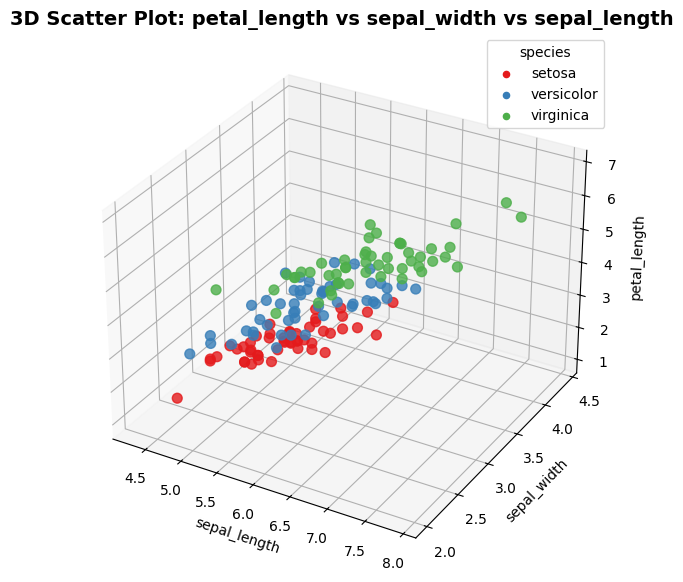

In [276]:
import seaborn as sns
df = sns.load_dataset("iris")
plot_3d_scatter(df, 'sepal_length', 'sepal_width', 'petal_length', color_feature='species', palette='Set1')

---
---
## **└─ (CCCNN) Facet Grid**

- A Facet Grid creates a matrix of subplots that display the relationship between variables, split by one or more categorical variables.
- It allows you to visualize the same kind of plot (e.g., scatter, histogram) across subsets of data arranged in a grid layout.

**✅ When to Use:**

- When you want to compare distributions or relationships across different groups or categories.
- To explore how a relationship or distribution varies by one or more categorical variables.
- When you have multiple categories and want to display them side-by-side for easy comparison.

**❌ When Not to Use:**

- If the dataset has too many categories, resulting in a cluttered or unreadable grid.
- When individual subgroup sizes are too small to produce meaningful plots.
- If you want to display summary statistics instead of visual distributions.

**⚠️ Tip**

- Limit the number of facets to keep the grid readable.
- Use consistent axis scales across plots to enable accurate comparisons.
- Add informative titles or labels for each facet.
- Use color, markers, or other aesthetics within each plot for richer insights.

In [248]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_facet_grid(df, x_feature, y_feature=None, kind='scatter', 
                    row=None, col=None, hue=None, palette='Set1', 
                    height=4, aspect=1, title=None):
    """
    Create a Seaborn FacetGrid plot with flexible options.

    Parameters:
        df (pd.DataFrame): Input dataset.
        x_feature (str): Feature for x-axis.
        y_feature (str or None): Feature for y-axis (required for scatter/line/kde).
        kind (str): Plot kind: 'scatter', 'line', 'hist', 'kde', 'box', 'violin', 'bar' (default 'scatter').
        row (str or None): Feature for row facet.
        col (str or None): Feature for column facet.
        hue (str or None): Feature for color grouping within facets.
        palette (str or list): Color palette for hue.
        height (float): Height of each facet subplot.
        aspect (float): Aspect ratio of each facet subplot.
        title (str or None): Overall title for the plot.

    Returns:
        None. Displays the FacetGrid plot.
    """

    # Validate features
    for feat in [x_feature, y_feature, row, col, hue]:
        if feat and feat not in df.columns:
            print(f"❌ Column '{feat}' not found in DataFrame.")
            return

    # Initialize FacetGrid
    g = sns.FacetGrid(df, row=row, col=col, hue=hue, palette=palette,
                      height=height, aspect=aspect, margin_titles=True)

    # Map plot kind
    if kind == 'scatter':
        if y_feature is None:
            print("❌ y_feature is required for scatter plot.")
            return
        g.map_dataframe(sns.scatterplot, x=x_feature, y=y_feature)
    elif kind == 'line':
        if y_feature is None:
            print("❌ y_feature is required for line plot.")
            return
        g.map_dataframe(sns.lineplot, x=x_feature, y=y_feature)
    elif kind == 'hist':
        g.map_dataframe(sns.histplot, x=x_feature, kde=False)
    elif kind == 'kde':
        g.map_dataframe(sns.kdeplot, x=x_feature, fill=True)
    elif kind == 'box':
        if y_feature is None:
            print("❌ y_feature is required for box plot.")
            return
        g.map_dataframe(sns.boxplot, x=x_feature, y=y_feature)
    elif kind == 'violin':
        if y_feature is None:
            print("❌ y_feature is required for violin plot.")
            return
        g.map_dataframe(sns.violinplot, x=x_feature, y=y_feature)
    elif kind == 'bar':
        if y_feature is None:
            print("❌ y_feature is required for bar plot.")
            return
        g.map_dataframe(sns.barplot, x=x_feature, y=y_feature)
    else:
        print(f"❌ Plot kind '{kind}' not supported.")
        return

    # Add legend if hue is specified
    if hue:
        g.add_legend(title=hue)

    # Adjust overall title
    if title:
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle(title, fontsize=16, fontweight='bold')

    plt.show()

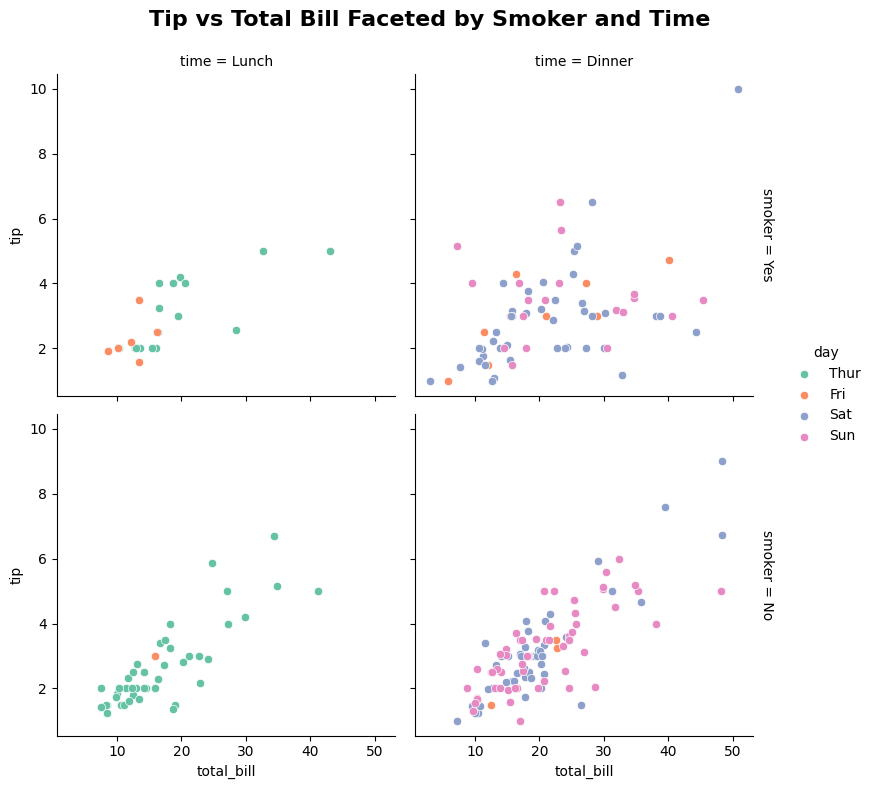

In [250]:
import seaborn as sns
df = sns.load_dataset("tips")

# Scatter plot of total_bill vs tip, faceted by smoker (row) and time (col), colored by day
plot_facet_grid(
    df, 
    x_feature='total_bill', 
    y_feature='tip', 
    kind='scatter', 
    row='smoker', 
    col='time', 
    hue='day', 
    palette='Set2', 
    height=4, 
    aspect=1,
    title="Tip vs Total Bill Faceted by Smoker and Time"
)

---
---
---